# Maradona 1986 

This notebook makes visuals for the blog post.

## 1. Bilardo's 3-5-2



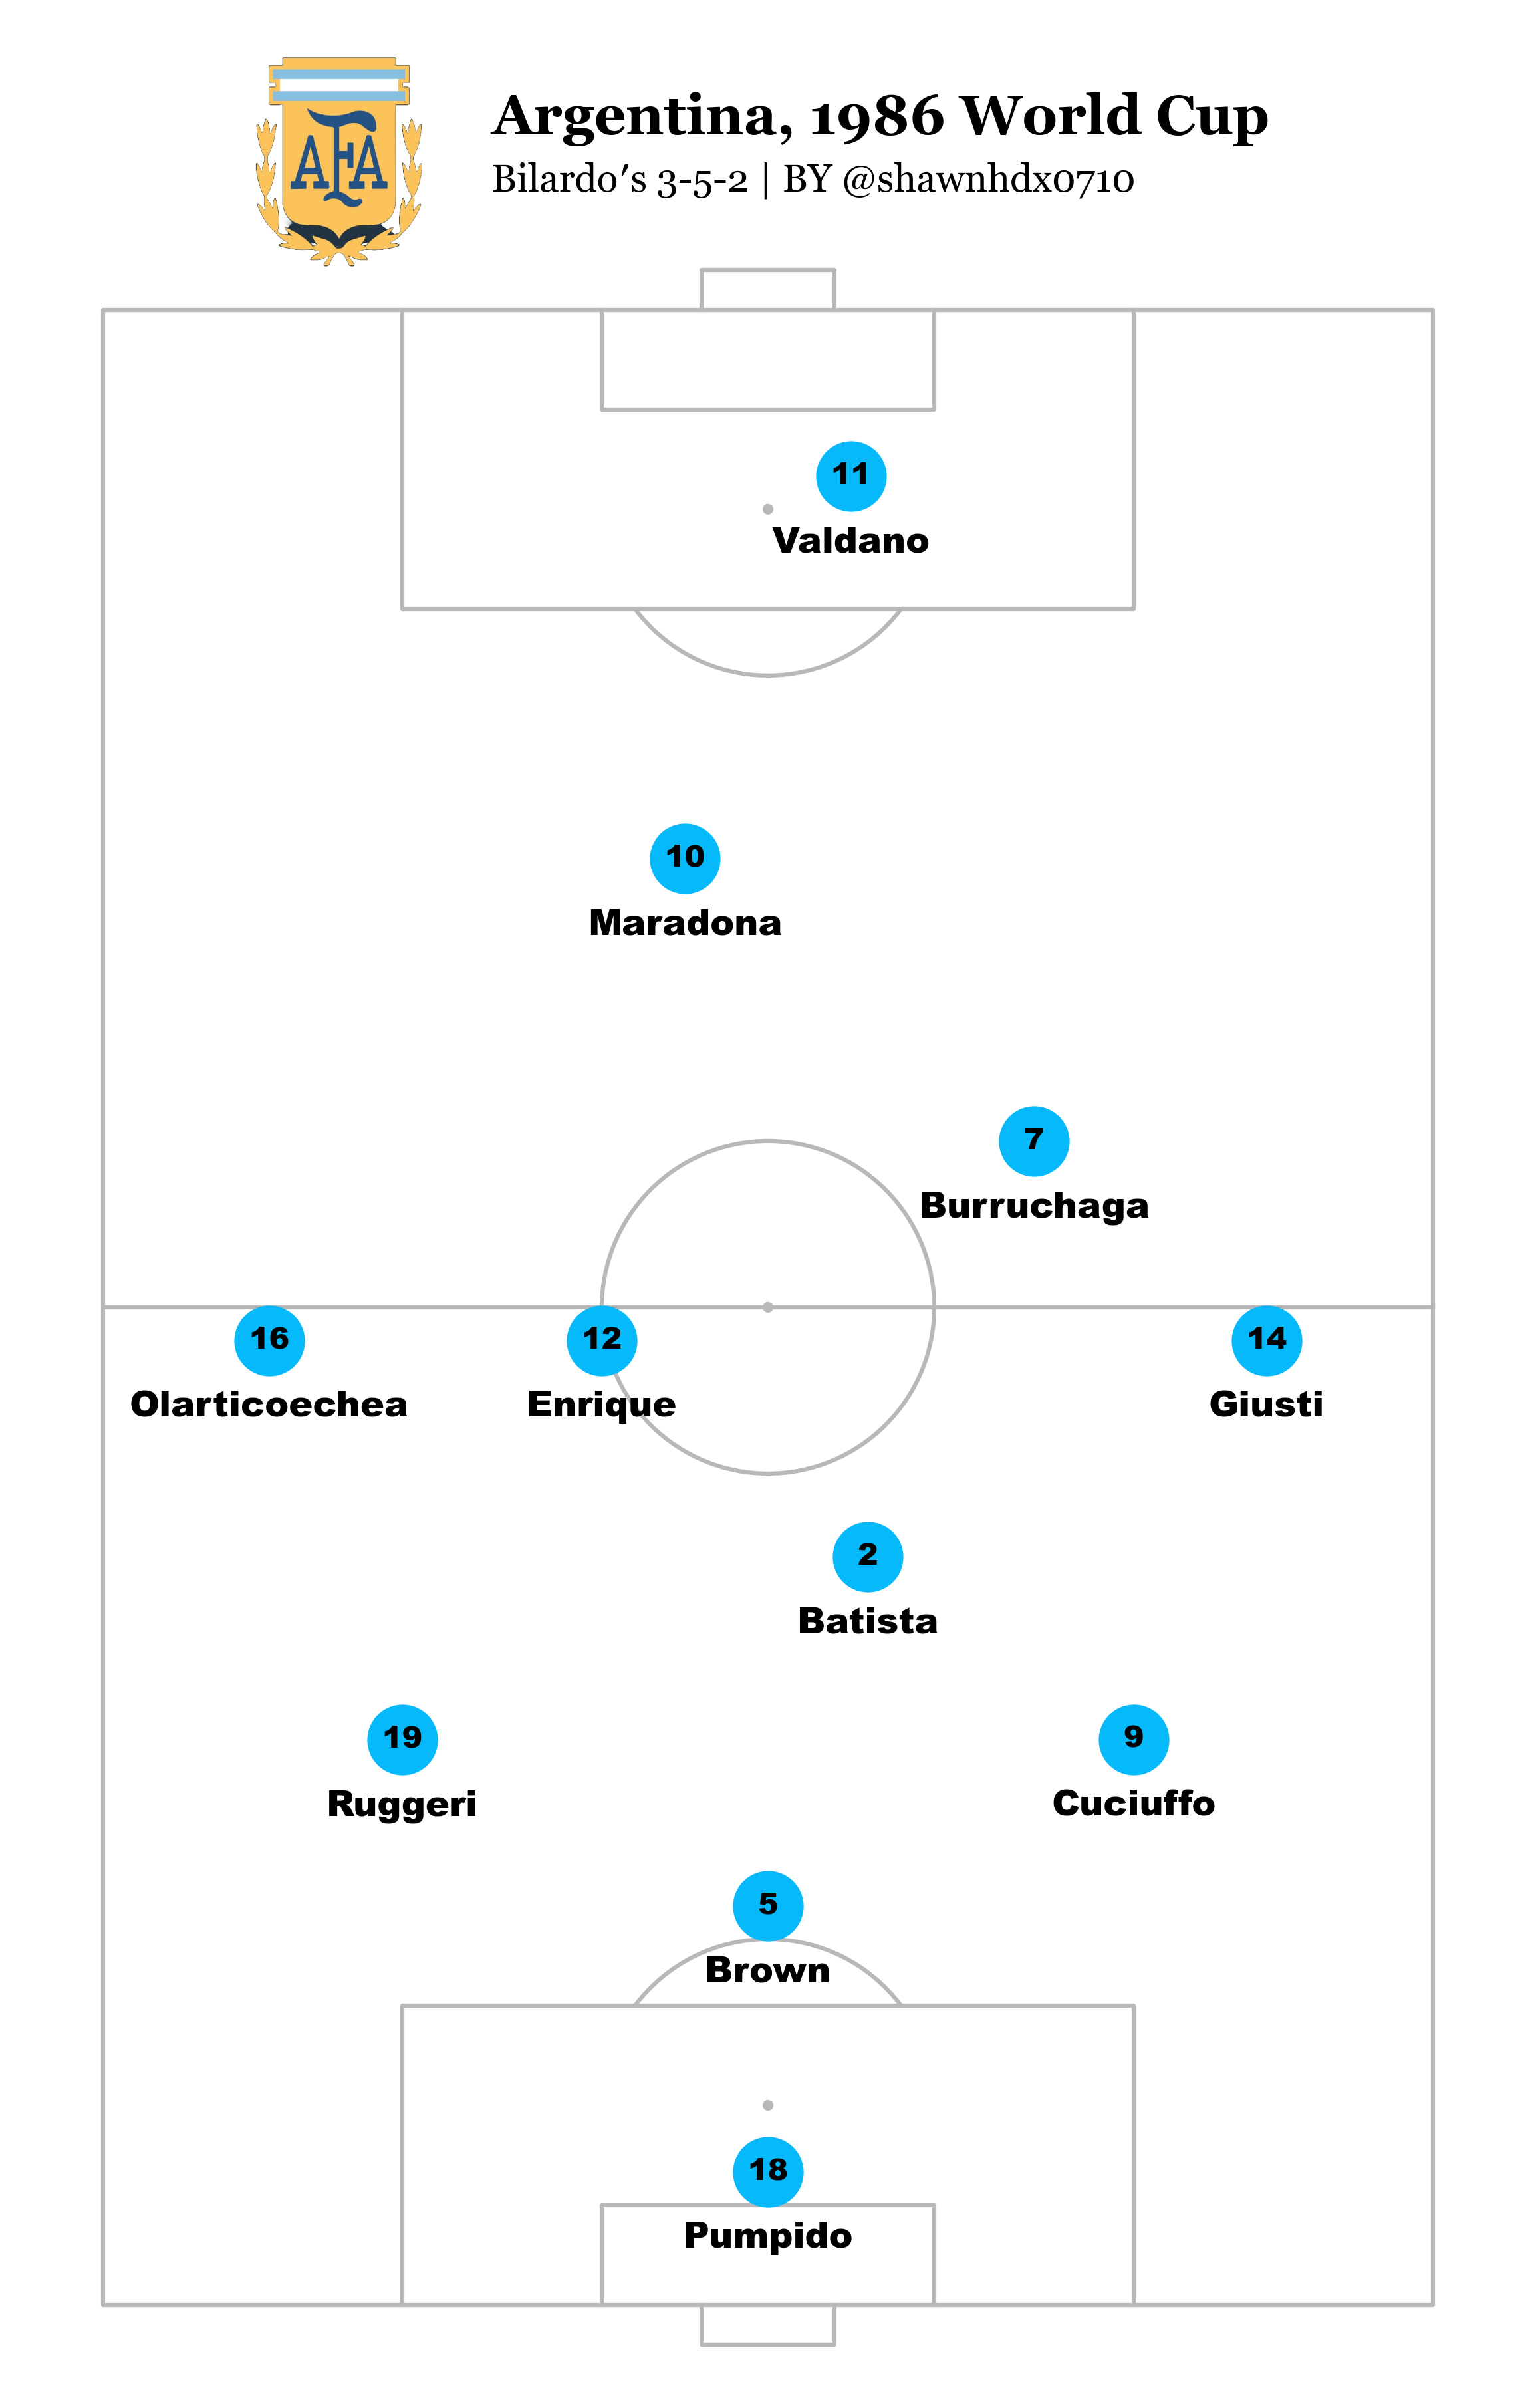

In [4]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import VerticalPitch

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300

players = [
    ('Pumpido', 18, 40, 8),
    ('Brown', 5, 40, 24),
    ('Ruggeri', 19, 18, 34),
    ('Cuciuffo', 9, 62, 34),
    ('Olarticoechea', 16, 10, 58),
    ('Enrique', 12, 30, 58),
    ('Batista', 2, 46, 45),
    ('Giusti', 14, 70, 58),
    ('Burruchaga', 7, 56, 70),
    ('Maradona', 10, 35, 87),
    ('Valdano', 11, 45, 110),
]

fig, ax = plt.subplots(figsize=(8, 12))
fig.patch.set_facecolor('#FFFFFF')

pitch = VerticalPitch(
    pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#B8B8B8',
    linewidth=1.5, half=False, goal_type='box',
    pad_top=5, pad_bottom=5, pad_left=5, pad_right=5,
)
pitch.draw(ax=ax)

for name, num, x, y in players:
    ax.scatter(x, y, s=650, c='#05b9fa', edgecolors='#FFFFFF',
               linewidths=0, zorder=5)
    ax.text(x, y, str(num), ha='center', va='center',
            color='#000000', fontsize=11, fontweight='bold',
            fontfamily='Arial Black', zorder=7)
    ax.text(x, y - 3, name, ha='center', va='top',
            color='#000000', fontsize=13, fontweight='bold',
            fontfamily='Arial Black', zorder=4)

badge = plt.imread('afa-badge.png')
imagebox = OffsetImage(badge, zoom=0.15)
ab = AnnotationBbox(imagebox, (0.38, 1.03),
                    xycoords='axes fraction', frameon=False,
                    box_alignment=(1.0, 0.5))
ax.add_artist(ab)

ax.text(0.315, 1.05, 'Argentina, 1986 World Cup',
        transform=ax.transAxes, ha='left', va='center',
        fontsize=20, fontfamily='Georgia', fontweight='bold',
        color='#000000')

ax.text(0.315, 1.03, "Bilardo\u2032s 3-5-2 | BY @shawnhdx0710",
        transform=ax.transAxes, ha='left', va='top',
        fontsize=14, fontfamily='Georgia', color='#000000')

plt.tight_layout()
plt.savefig('formation-352.svg', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 2. Load event data

In [6]:
import json as _json
import urllib.request
import ssl
from collections import Counter

# Bypass SSL verification (required on restricted networks)
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

MATCHES = {
    'QF vs England': 3750191,
    'SF vs Belgium': 3889148,
    'Final vs West Germany': 3889149,
}

BASE = 'https://raw.githubusercontent.com/statsbomb/open-data/master/data/events'

all_events = []
for label, match_id in MATCHES.items():
    url = f'{BASE}/{match_id}.json'
    print(f'Fetching {label}...')
    with urllib.request.urlopen(url, context=ctx) as resp:
        events = _json.loads(resp.read().decode())
    for e in events:
        e['_match'] = label
    all_events.extend(events)
    print(f'  {label}: {len(events)} events')

print(f'\nTotal: {len(all_events)} events across 3 matches')

types = Counter(e['type']['name'] for e in all_events)
print('\nEvent types:')
for t, c in types.most_common(12):
    print(f'  {t}: {c}')

Fetching QF vs England...
  QF vs England: 2748 events
Fetching SF vs Belgium...
  SF vs Belgium: 3054 events
Fetching Final vs West Germany...
  Final vs West Germany: 2669 events

Total: 8471 events across 3 matches

Event types:
  Pass: 2261
  Ball Receipt*: 2077
  Carry: 1852
  Pressure: 637
  Ball Recovery: 294
  Duel: 191
  Clearance: 157
  Foul Committed: 123
  Dribble: 117
  Foul Won: 116
  Goal Keeper: 107
  Block: 100


### Explore one event's structure

Pick a single event from the England match and inspect its full JSON.

In [ ]:
# Load just one match and print one event of each major type
import json as _json
import requests

england = requests.get(f'{BASE}/3750191.json').json()
print(f'Total events: {len(england)}')

# Pick one example of each key event type
seen = set()
for e in england:
    t = e['type']['name']
    if t not in seen and t in ('Pass', 'Shot', 'Dribble', 'Carry', 'Pressure', 'Starting XI'):
        seen.add(t)
        print(f"\n{'='*60}")
        print(f"TYPE: {t}")
        print(f"{'='*60}")
        print(_json.dumps(e, indent=2, ensure_ascii=False)[:2000])
        if len(seen) >= 6:
            break

Total events: 2748

TYPE: Starting XI
{
  "id": "98e24382-faec-4ca1-a87e-929a28e7116d",
  "index": 1,
  "period": 1,
  "timestamp": "00:00:00.000",
  "minute": 0,
  "second": 0,
  "type": {
    "id": 35,
    "name": "Starting XI"
  },
  "possession": 1,
  "possession_team": {
    "id": 779,
    "name": "Argentina"
  },
  "play_pattern": {
    "id": 1,
    "name": "Regular Play"
  },
  "team": {
    "id": 779,
    "name": "Argentina"
  },
  "duration": 0.0,
  "tactics": {
    "formation": 3511,
    "lineup": [
      {
        "player": {
          "id": 38640,
          "name": "Neri Alberto Pumpido Barrinat"
        },
        "position": {
          "id": 1,
          "name": "Goalkeeper"
        },
        "jersey_number": 18
      },
      {
        "player": {
          "id": 38643,
          "name": "José Luis Cuciuffo"
        },
        "position": {
          "id": 3,
          "name": "Right Center Back"
        },
        "jersey_number": 9
      },
      {
        "player": 

## 3. Maradona's events

In [7]:
# Find Maradona's player_id (consistent across all matches)
maradona_id = None
for e in all_events:
    p = e.get('player')
    if p and isinstance(p, dict) and 'maradona' in p.get('name', '').lower():
        maradona_id = p['id']
        print(f"Found: id={maradona_id}, name='{p['name']}'")
        break

# Filter by player_id (reliable, never varies)
maradona_events = [e for e in all_events if e.get('player', {}).get('id') == maradona_id]
print(f'\nMaradona total events: {len(maradona_events)}')

# Per-match breakdown
from collections import Counter
for label in ['QF vs England', 'SF vs Belgium', 'Final vs West Germany']:
    m_evts = [e for e in maradona_events if e['_match'] == label]
    print(f'\n{label}: {len(m_evts)} events')
    types = Counter(e['type']['name'] for e in m_evts)
    for t, c in types.most_common(8):
        print(f'  {t}: {c}')

Found: id=38641, name='Diego Armando Maradona'

Maradona total events: 716

QF vs England: 229 events
  Carry: 64
  Ball Receipt*: 61
  Pass: 40
  Dribble: 14
  Pressure: 12
  Foul Won: 8
  Shot: 7
  Dispossessed: 6

SF vs Belgium: 259 events
  Ball Receipt*: 87
  Carry: 66
  Pass: 60
  Pressure: 10
  Foul Won: 7
  Shot: 6
  Miscontrol: 6
  Dribble: 6

Final vs West Germany: 228 events
  Ball Receipt*: 72
  Carry: 52
  Pass: 48
  Ball Recovery: 11
  Foul Won: 9
  Dispossessed: 7
  Pressure: 6
  Miscontrol: 6


## 4. Maradona's goals and assists

Find every goal involvement across the three knockout matches.

In [8]:
# ── Find all goals in the three matches ──────────────────────────
goal_events = []
for e in all_events:
    if e['type']['name'] == 'Shot':
        shot = e.get('shot', {})
        outcome = shot.get('outcome', {}).get('name', '')
        if outcome == 'Goal':
            goal_events.append(e)

print(f'Total goals found: {len(goal_events)}')

# Show every goal
for g in goal_events:
    player = g.get('player', {}).get('name', '?')
    minute = g.get('minute', '?')
    second = g.get('second', 0)
    match = g['_match']
    # Check for assist info in the shot
    shot = g.get('shot', {})
    technique = shot.get('technique', {}).get('name', '')
    body_part = shot.get('body_part', {}).get('name', '')
    # StatsBomb sometimes stores key_pass_id for assists
    key_pass_id = shot.get('key_pass_id', None)
    
    tag = ''
    if player == maradona_id or (g.get('player', {}).get('name', '').lower().find('maradona') >= 0):
        tag = ' ⭐ MARADONA GOAL'
    
    print(f'{match} | {minute}:{second:02d} | {player} | {body_part} {technique} | key_pass_id={key_pass_id}{tag}')

# ── Check field structure of a goal event ───────────────────────
print('\n--- Full structure of first goal event ---')
if goal_events:
    # Print keys to see what fields are available
    g = goal_events[0]
    print('Top-level keys:', list(g.keys()))
    print('Shot keys:', list(g.get('shot', {}).keys()))

Total goals found: 10
QF vs England | 50:27 | Diego Armando Maradona | Other Normal | key_pass_id=None ⭐ MARADONA GOAL
QF vs England | 54:18 | Diego Armando Maradona | Left Foot Normal | key_pass_id=3c9db676-5edd-49af-8508-ab7d462ce25d ⭐ MARADONA GOAL
QF vs England | 80:37 | Gary Lineker | Head Normal | key_pass_id=dd0466b2-7939-4922-8d91-ac1659f6ffa6
SF vs Belgium | 51:02 | Diego Armando Maradona | Left Foot Half Volley | key_pass_id=821e84fc-04fd-4a06-b434-d6e3525a26d7 ⭐ MARADONA GOAL
SF vs Belgium | 62:45 | Diego Armando Maradona | Left Foot Normal | key_pass_id=c5924747-e1a3-4566-85af-29e2589fb718 ⭐ MARADONA GOAL
Final vs West Germany | 21:52 | José Luis Brown | Head Normal | key_pass_id=44d5bea6-b1e4-4449-a135-4c2a86622f7c
Final vs West Germany | 55:38 | Jorge Alberto Francisco Valdano Castellano | Right Foot Normal | key_pass_id=06acb882-8647-4f3a-a92c-cb7364c22f1b
Final vs West Germany | 73:08 | Karl-Heinz Rummenigge | Right Foot Half Volley | key_pass_id=None
Final vs West Germ

### Assists

If the shot has a `key_pass_id`, we can look up the assist provider.

In [ ]:
# ── Look up assists using key_pass_id ────────────────────────────
# Build an id -> event lookup
event_by_id = {e['id']: e for e in all_events}

for g in goal_events:
    kp_id = g.get('shot', {}).get('key_pass_id')
    scorer = g.get('player', {}).get('name', '?')
    match = g['_match']
    minute = g.get('minute', '?')
    
    if kp_id and kp_id in event_by_id:
        assist_evt = event_by_id[kp_id]
        assister = assist_evt.get('player', {}).get('name', '?')
        assist_type = assist_evt['type']['name']
        tag = ' ⭐ MARADONA ASSIST' if assist_evt.get('player', {}).get('id') == maradona_id else ''
        print(f'{match} | {minute}\u2032 | {scorer} goal <- {assister} ({assist_type}){tag}')
    else:
        # No key_pass_id — try to find the pass before the goal manually
        g_idx = all_events.index(g)
        # Look backwards for a pass from a teammate
        for prev in reversed(all_events[max(0, g_idx-10):g_idx]):
            if prev['type']['name'] == 'Pass':
                prev_player = prev.get('player', {}).get('name', '?')
                tag = ' ⭐ MARADONA ASSIST' if prev.get('player', {}).get('id') == maradona_id else ''
                print(f'{match} | {minute}\u2032 | {scorer} goal <- likely {prev_player} (Pass before shot){tag}')
                break

QF vs England | 50′ | Diego Armando Maradona goal <- likely Diego Armando Maradona (Pass before shot) ⭐ MARADONA ASSIST
QF vs England | 54′ | Diego Armando Maradona goal <- Héctor Adolfo Enrique (Pass)
QF vs England | 80′ | Gary Lineker goal <- John Barnes (Pass)
SF vs Belgium | 51′ | Diego Armando Maradona goal <- Jorge Luis Burruchaga (Pass)
SF vs Belgium | 62′ | Diego Armando Maradona goal <- José Luis Cuciuffo (Pass)
Final vs West Germany | 21′ | José Luis Brown goal <- Jorge Luis Burruchaga (Pass)
Final vs West Germany | 55′ | Jorge Alberto Francisco Valdano Castellano goal <- Héctor Adolfo Enrique (Pass)
Final vs West Germany | 73′ | Karl-Heinz Rummenigge goal <- likely Andreas Brehme (Pass before shot)
Final vs West Germany | 82′ | Rudi Völler goal <- Thomas Berthold (Pass)
Final vs West Germany | 85′ | Jorge Luis Burruchaga goal <- Diego Armando Maradona (Pass) ⭐ MARADONA ASSIST


## 5. Maradona's shot map

All shot attempts across the three knockout matches, with goals highlighted.

In [9]:
print(f'maradona_events count: {len(maradona_events)}')
shots = [e for e in maradona_events if e['type']['name'] == 'Shot']
print(f'Shots found: {len(shots)}')

goals = []
misses = []
for s in shots:
    loc = s.get('location')
    if loc is None:
        continue
    # StatsBomb raw: [sb_x, sb_y] where sb_x=0..120 (length), sb_y=0..80 (width)
    # VerticalPitch expects: (x, y) where x=0..80 (width), y=0..120 (length)
    sb_x, sb_y = loc
    x, y = sb_y, sb_x
    
    outcome = s.get('shot', {}).get('outcome', {}).get('name', '?')
    minute = s.get('minute', 0)
    match = s['_match']
    body_part = s.get('shot', {}).get('body_part', {}).get('name', '')
    
    entry = (x, y, f"{minute}'\n{match}\n{body_part}", outcome)
    if outcome == 'Goal':
        goals.append(entry)
    else:
        misses.append(entry)

print(f'\nGoals: {len(goals)}')
print(f'Non-goal shots: {len(misses)}')
for g in goals:
    print(f"  GOAL: ({g[0]:.1f}, {g[1]:.1f}) | {g[2].replace(chr(10), ' | ')}")
for m in misses:
    print(f"  Miss: ({m[0]:.1f}, {m[1]:.1f}) | {m[2].replace(chr(10), ' | ')}")

maradona_events count: 716
Shots found: 17

Goals: 4
Non-goal shots: 13
  GOAL: (40.1, 110.8) | 50' | QF vs England | Other
  GOAL: (49.5, 113.4) | 54' | QF vs England | Left Foot
  GOAL: (46.9, 107.8) | 51' | SF vs Belgium | Left Foot
  GOAL: (31.9, 111.2) | 62' | SF vs Belgium | Left Foot
  Miss: (55.3, 93.9) | 9' | QF vs England | Left Foot
  Miss: (47.7, 97.9) | 32' | QF vs England | Left Foot
  Miss: (61.2, 98.5) | 34' | QF vs England | Left Foot
  Miss: (25.4, 101.4) | 36' | QF vs England | Left Foot
  Miss: (52.8, 97.3) | 85' | QF vs England | Left Foot
  Miss: (34.8, 115.4) | 4' | SF vs Belgium | Left Foot
  Miss: (26.8, 106.5) | 5' | SF vs Belgium | Left Foot
  Miss: (48.6, 91.2) | 8' | SF vs Belgium | Left Foot
  Miss: (28.1, 111.5) | 66' | SF vs Belgium | Left Foot
  Miss: (43.7, 98.5) | 26' | Final vs West Germany | Left Foot
  Miss: (59.7, 106.3) | 81' | Final vs West Germany | Left Foot
  Miss: (29.7, 92.3) | 84' | Final vs West Germany | Left Foot
  Miss: (33.2, 97.7) | 

In [10]:
# ── Compute shot map metrics ───────────────────────────────────────
# Pre-compute all panel values before plotting.
# Run after c4 and c6 (needs all_events, maradona_events).

from collections import Counter

TOTAL_MIN = 270  # 3 matches × 90 min
N_MATCHES = 3

# ── Filter Maradona's shots ────────────────────────────────────
shots = [e for e in maradona_events if e['type']['name'] == 'Shot']
n_shots = len(shots)

# Outcomes
n_goals   = sum(1 for s in shots if s['shot']['outcome']['name'] == 'Goal')
n_saved   = sum(1 for s in shots if s['shot']['outcome']['name'] == 'Saved')
n_blocked = sum(1 for s in shots if s['shot']['outcome']['name'] == 'Blocked')
n_off_t   = sum(1 for s in shots if s['shot']['outcome']['name'] == 'Off T')

# Shot accuracy: (Goal + Saved) / (Total − Blocked)
# Blocked shots are excluded from the denominator — standard convention.
n_on_target   = n_goals + n_saved
n_excl_blocks = n_shots - n_blocked
shot_accuracy = n_on_target / n_excl_blocks * 100 if n_excl_blocks > 0 else 0

# Conversion rate
conversion = n_goals / n_shots * 100 if n_shots > 0 else 0

# ── xG ─────────────────────────────────────────────────────────
total_xg = sum(s['shot']['statsbomb_xg'] for s in shots)
overperformance = n_goals - total_xg

# Body part distribution (for caption)
body_parts = Counter(s['shot']['body_part']['name'] for s in shots)

# Per 90
shots_p90 = n_shots / N_MATCHES
goals_p90 = n_goals / N_MATCHES

# ── Print summary ──────────────────────────────────────────────
print(f'Shots: {n_shots} ({shots_p90:.1f} per 90)')
print(f'Goals: {n_goals} ({goals_p90:.2f} per 90)')
print(f'On-target: {n_on_target} (Goal {n_goals} + Saved {n_saved})')
print(f'Off-target: {n_off_t}, Blocked: {n_blocked}')
print(f'Shot accuracy: {shot_accuracy:.1f}% ({n_on_target}/{n_excl_blocks}, excl. {n_blocked} blocked)')
print(f'Conversion: {conversion:.1f}% ({n_goals}/{n_shots})')
print(f'Total xG: {total_xg:.3f}')
print(f'Overperformance: {overperformance:+.2f} (scored {n_goals} vs {total_xg:.2f} xG)')
print(f'Body parts: {dict(body_parts)}')

# Package for the plotting cell
shot_metrics = {
    'n_shots': n_shots,
    'n_goals': n_goals,
    'shots_p90': shots_p90,
    'goals_p90': goals_p90,
    'shot_accuracy': shot_accuracy,
    'conversion': conversion,
    'total_xg': total_xg,
    'overperformance': overperformance,
    'n_on_target': n_on_target,
    'n_excl_blocks': n_excl_blocks,
    'n_blocked': n_blocked,
    'body_parts': body_parts,
}


Shots: 17 (5.7 per 90)
Goals: 4 (1.33 per 90)
On-target: 7 (Goal 4 + Saved 3)
Off-target: 4, Blocked: 6
Shot accuracy: 63.6% (7/11, excl. 6 blocked)
Conversion: 23.5% (4/17)
Total xG: 2.268
Overperformance: +1.73 (scored 4 vs 2.27 xG)
Body parts: {'Left Foot': 16, 'Other': 1}


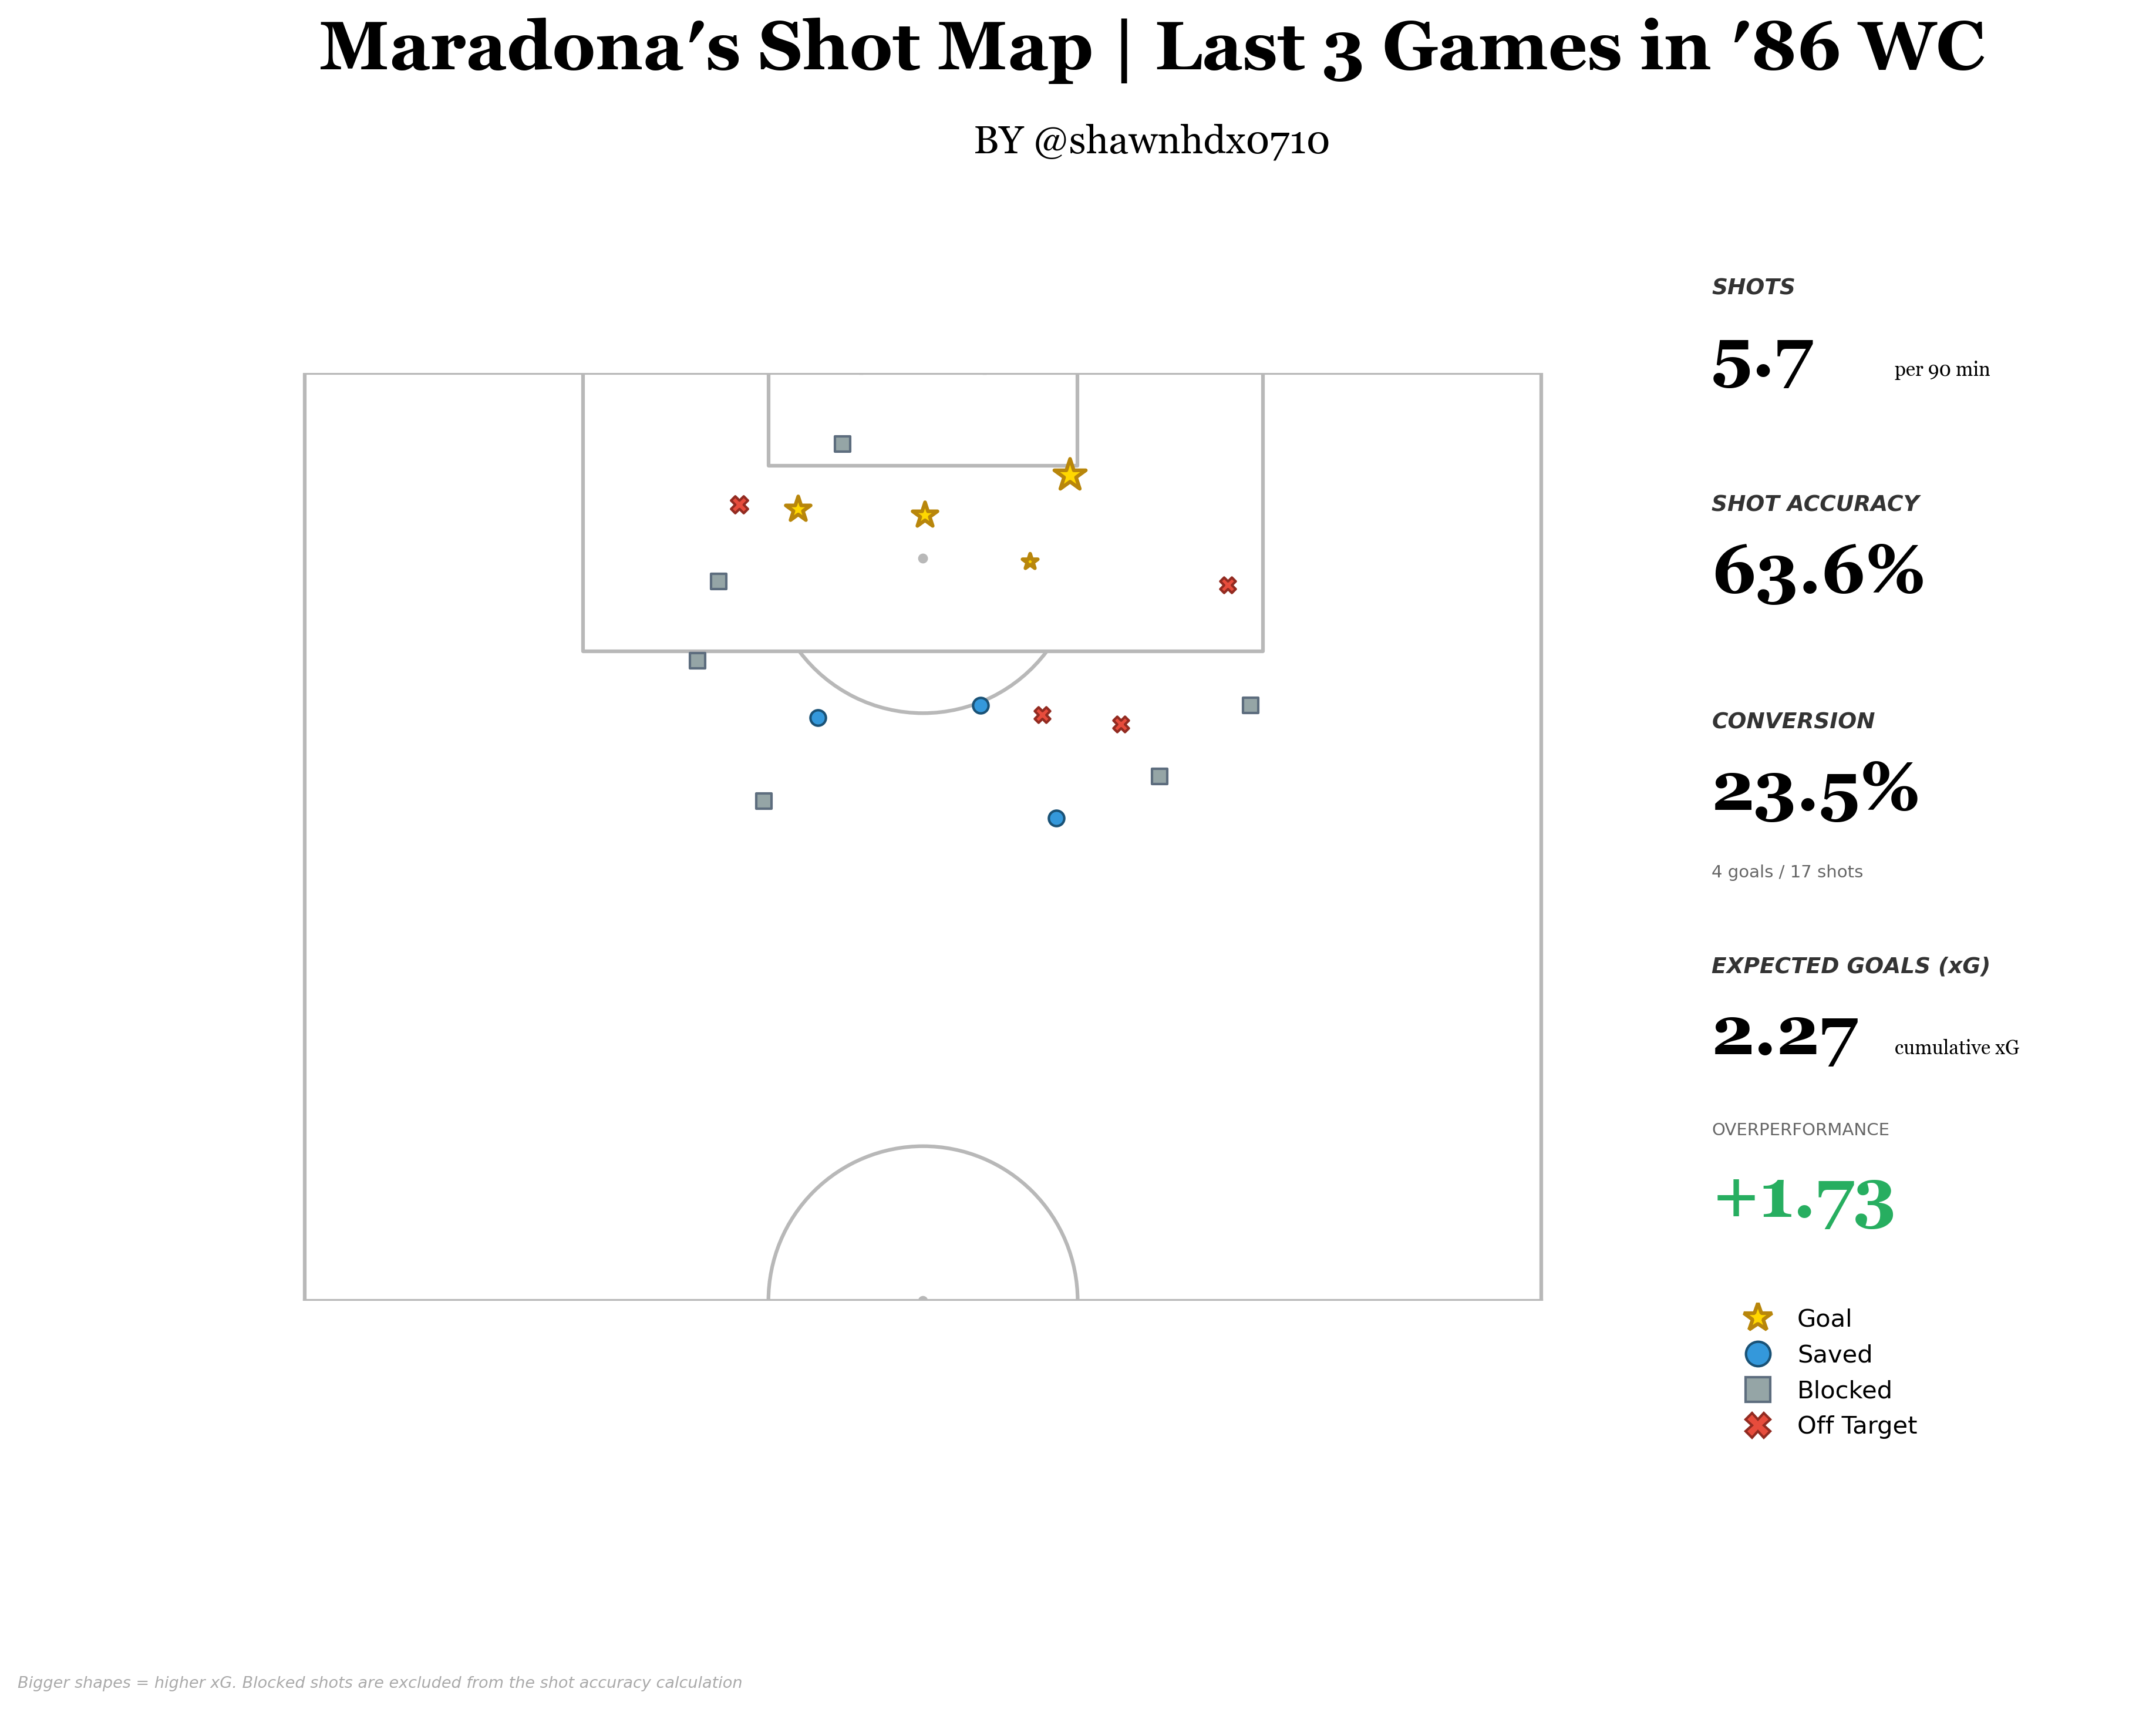

In [33]:
# ── Shot map + stats panel ────────────────────────────────────────
# Requires: shot_metrics from c6e2_metrics, maradona_events from c6

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mplsoccer import VerticalPitch
from matplotlib.lines import Line2D

def v_swap(loc):
    return (loc[1], loc[0])

shots = [e for e in maradona_events if e['type']['name'] == 'Shot']

# ── GridSpec layout ────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#FFFFFF')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.06)
ax = fig.add_subplot(gs[0, 0])
ax_stats = fig.add_subplot(gs[0, 1])

# ── Title ──────────────────────────────────────────────────────
fig.suptitle(
    "Maradona\u2032s Shot Map | Last 3 Games in \u203286 WC",
    fontsize=28, fontfamily='Georgia', fontweight='bold',
    color='#000000', x=0.5, y=0.96, ha='center', va='top'
)
fig.text(0.5, 0.9, 'BY @shawnhdx0710',
         fontsize=16, fontfamily='Georgia', color='#000000',
         ha='center', va='top')

# ── Pitch ──────────────────────────────────────────────────────
pitch = VerticalPitch(
    pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#B8B8B8',
    linewidth=1.5, half=False, goal_type='box',
    pad_top=5, pad_bottom=5, pad_left=5, pad_right=5,
)
pitch.draw(ax=ax)
ax.set_ylim(60, 120)  # crop to attacking half

# ── Plot shots by outcome ──────────────────────────────────────
for s in shots:
    loc = s.get('location')
    if loc is None:
        continue
    sx, sy = v_swap(loc)
    outcome = s['shot']['outcome']['name']
    xg = s['shot']['statsbomb_xg']
    size = max(40, xg * 300)

    if outcome == 'Goal':
        ax.scatter(sx, sy, s=size, c='#FFD700', edgecolors='#B8860B',
                   linewidths=1.5, zorder=10, marker='*')
    elif outcome == 'Saved':
        ax.scatter(sx, sy, s=size, c='#3498db', edgecolors='#1a5276',
                   linewidths=1, zorder=8, marker='o')
    elif outcome == 'Blocked':
        ax.scatter(sx, sy, s=size, c='#95a5a6', edgecolors='#5d6d7e',
                   linewidths=1, zorder=7, marker='s')
    else:
        ax.scatter(sx, sy, s=size, c='#e74c3c', edgecolors='#922b21',
                   linewidths=1, zorder=7, marker='X')

# ── Stats Panel ────────────────────────────────────────────────
ax_stats.axis('off')
ax_stats.set_xlim(0, 1)
ax_stats.set_ylim(0, 1)

m = shot_metrics
LEFT = 0.08

# Each block: label (y), value (y - 0.06), subtitle (y - 0.12)
# Blocks are spaced 0.15–0.17 apart vertically.

y = 0.90
# ── Block 1: Shots ──
ax_stats.text(LEFT, y, 'SHOTS', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["shots_p90"]:.1f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(0.475, y - 0.06, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color='#000000', va='baseline')

y -= 0.16
# ── Block 3: Shot Accuracy ──
ax_stats.text(LEFT, y, 'SHOT ACCURACY', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["shot_accuracy"]:.1f}%', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')

y -= 0.16
# ── Block 4: Conversion ──
ax_stats.text(LEFT, y, 'CONVERSION', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["conversion"]:.1f}%', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(LEFT, y - 0.11, f'{m["n_goals"]} goals / {m["n_shots"]} shots',
              fontsize=7, fontfamily='sans-serif', color='#666666', va='baseline')

y -= 0.18
# ── Section divider: xG ──
ax_stats.text(LEFT, y, 'EXPECTED GOALS (xG)', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')

y -= 0.06
# ── Block 5: Cumulative xG ──
ax_stats.text(LEFT, y, f'{m["total_xg"]:.2f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(0.475, y, 'cumulative xG', fontsize=8,
              fontfamily='Georgia', color='#000000', va='baseline')

y -= 0.06
# ── Block 6: Overperformance ──
over_color = '#27ae60' if m['overperformance'] >= 0 else '#e74c3c'
over_sign = '+' if m['overperformance'] >= 0 else ''
ax_stats.text(LEFT, y, 'OVERPERFORMANCE', fontsize=7, fontfamily='sans-serif',
              color='#666666', va='baseline')
ax_stats.text(LEFT, y - 0.06, f'{over_sign}{m["overperformance"]:.2f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color=over_color, va='baseline')


# ── Legend ──────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0],marker='*', color='#FFD700', markeredgecolor='#B8860B',
           markeredgewidth=1.5, markersize=12, linestyle='', label='Goal'),
    Line2D([0],[0], marker='o', color='#3498db', markeredgecolor='#1a5276',
           markeredgewidth=1, markersize=10, linestyle='', label='Saved'),
    Line2D([0], [0], marker='s', color='#95a5a6', markeredgecolor='#5d6d7e',
           markeredgewidth=1, markersize=10, linestyle='', label='Blocked'),
    Line2D([0], [0], marker='X', color='#e74c3c', markeredgecolor='#922b21',
           markeredgewidth=1, markersize=10, linestyle='', label='Off Target'),
]
leg = ax_stats.legend(handles=legend_elements, loc='lower left',
                       fontsize=10, frameon=False, ncol=1,
                       bbox_to_anchor=(0.08, 0.04),
                       handletextpad=0.6, labelspacing=0.5)
for text in leg.get_texts():
    text.set_color("#000000")

# ── Methodology footnote ───────────────────────────────────────
fig.text(0.04, 0.01,
         'Bigger shapes = higher xG. Blocked shots are excluded from the shot accuracy calculation',
         fontsize=6.5, fontfamily='sans-serif', color='#AAAAAA',
         ha='left', va='bottom', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.savefig('./maradona-shot-map.svg', dpi=150, bbox_inches='tight',
            facecolor='#FFFFFF', edgecolor='none')
plt.show()


## 6. Maradona's Pass Map

Every pass — colored by outcome: regular, key pass (led to a shot), or assist (led to a goal).

In [13]:
# ── Understand pass & shot linkage ────────────────────────────────
import json as _json
from collections import Counter

# 1. All passes by Maradona
maradona_passes = [e for e in maradona_events if e['type']['name'] == 'Pass']
print(f'All passes by Maradona: {len(maradona_passes)}')

# 2. All shots (any player) — build a set of key_pass_ids
all_shots = [e for e in all_events if e['type']['name'] == 'Shot']
print(f'All shots (any player): {len(all_shots)}')

# Collect every key_pass_id from shots
key_pass_ids = set()       # passes that led to ANY shot
assist_ids = set()          # passes that led to a GOAL
for s in all_shots:
    kp_id = s.get('shot', {}).get('key_pass_id')
    if kp_id is not None:
        key_pass_ids.add(kp_id)
        outcome = s.get('shot', {}).get('outcome', {}).get('name', '')
        if outcome == 'Goal':
            assist_ids.add(kp_id)

print(f'Unique key_pass_ids (led to a shot): {len(key_pass_ids)}')
print(f'Unique assist_ids (led to a goal): {len(assist_ids)}')

# 3. Classify Maradona's passes
regular, key, assists = [], [], []
for p in maradona_passes:
    pid = p['id']
    loc = p.get('location')
    end_loc = p.get('pass', {}).get('end_location')
    if loc is None or end_loc is None:
        continue
    if pid in assist_ids:
        assists.append(p)
    elif pid in key_pass_ids:
        key.append(p)
    else:
        regular.append(p)

print(f'\nMaradona passes — Regular: {len(regular)}, Key: {len(key)}, Assists: {len(assists)}')

# 4. Show structure of one assist pass
if assists:
    print('\n--- Full structure of an ASSIST pass ---')
    print(_json.dumps(assists[0], indent=2, ensure_ascii=False)[:1500])

All passes by Maradona: 148
All shots (any player): 88
Unique key_pass_ids (led to a shot): 59
Unique assist_ids (led to a goal): 8

Maradona passes — Regular: 135, Key: 12, Assists: 1

--- Full structure of an ASSIST pass ---
{
  "id": "f10ec5e7-4ff4-4be6-9dc1-f75862210dfe",
  "index": 2522,
  "period": 2,
  "timestamp": "00:40:02.440",
  "minute": 85,
  "second": 2,
  "type": {
    "id": 30,
    "name": "Pass"
  },
  "possession": 176,
  "possession_team": {
    "id": 779,
    "name": "Argentina"
  },
  "play_pattern": {
    "id": 3,
    "name": "From Free Kick"
  },
  "team": {
    "id": 779,
    "name": "Argentina"
  },
  "player": {
    "id": 38641,
    "name": "Diego Armando Maradona"
  },
  "position": {
    "id": 18,
    "name": "Right Attacking Midfield"
  },
  "location": [
    57.6,
    51.1
  ],
  "duration": 1.189283,
  "under_pressure": true,
  "related_events": [
    "a1073e21-a46b-4d34-9063-5424ef1e3557",
    "194a7244-d512-427b-9e73-8116248a626a"
  ],
  "pass": {
    "

In [14]:
# ── Compute pass map metrics ───────────────────────────────────────
# Pre-compute all panel values before plotting.
# Requires: all_events from c4, maradona_events from c6.

from collections import Counter

TOTAL_MIN = 270
N_MATCHES = 3

# ── Filter Maradona's passes ────────────────────────────────────
passes = [e for e in maradona_events if e['type']['name'] == 'Pass']
n_passes = len(passes)

# Completion: no 'outcome' field = complete
def pass_is_complete(p):
    outcome = p.get('pass', {}).get('outcome')
    return outcome is None or outcome == {} or outcome.get('name') == 'Complete'

n_complete = sum(1 for p in passes if pass_is_complete(p))
completion_pct = n_complete / n_passes * 100 if n_passes > 0 else 0

# ── Key passes & assists ────────────────────────────────────────
all_shots = [e for e in all_events if e['type']['name'] == 'Shot']
key_pass_ids = set()
assist_ids = set()
for s in all_shots:
    kpid = s.get('shot', {}).get('key_pass_id')
    if kpid:
        key_pass_ids.add(kpid)
        if s['shot']['outcome']['name'] == 'Goal':
            assist_ids.add(kpid)

mara_key_passes = [p for p in passes if p['id'] in key_pass_ids]
mara_assists    = [p for p in passes if p['id'] in assist_ids]
n_key = len(mara_key_passes)
n_ast = len(mara_assists)

# ── Passes into the box ─────────────────────────────────────────
BOX_X_MIN, BOX_X_MAX = 102, 120
BOX_Y_MIN, BOX_Y_MAX = 18, 62

box_passes = 0
box_complete = 0
for p in passes:
    loc = p.get('location')
    end = p.get('pass', {}).get('end_location')
    if not loc or not end:
        continue
    # Start strictly outside the box
    starts_outside = (loc[0] < BOX_X_MIN or loc[1] < BOX_Y_MIN or loc[1] > BOX_Y_MAX)
    ends_inside    = (BOX_X_MIN <= end[0] <= BOX_X_MAX and BOX_Y_MIN <= end[1] <= BOX_Y_MAX)
    if starts_outside and ends_inside:
        box_passes += 1
        if pass_is_complete(p):
            box_complete += 1

# ── Progressive passes ──────────────────────────────────────────
# Definition: forward displacement >= 20 sb_x OR ends in penalty area
PROG_DX = 20
prog_passes = 0
prog_complete = 0
for p in passes:
    loc = p.get('location')
    end = p.get('pass', {}).get('end_location')
    if not loc or not end:
        continue
    dx = end[0] - loc[0]
    if dx >= PROG_DX or end[0] >= BOX_X_MIN:
        prog_passes += 1
        if pass_is_complete(p):
            prog_complete += 1

# ── Directional distribution ────────────────────────────────────
LEFT, CENTER, RIGHT = (0, 25), (25, 55), (55, 80)
dir_counts = {'Left': 0, 'Central': 0, 'Right': 0}
dir_comps  = {'Left': 0, 'Central': 0, 'Right': 0}

for p in passes:
    end = p.get('pass', {}).get('end_location')
    if not end:
        continue
    y = end[1]
    if LEFT[0] <= y <= LEFT[1]:
        zone = 'Left'
    elif RIGHT[0] <= y <= RIGHT[1]:
        zone = 'Right'
    else:
        zone = 'Central'
    dir_counts[zone] += 1
    if pass_is_complete(p):
        dir_comps[zone] += 1

# ── Per 90 ──────────────────────────────────────────────────────
passes_p90    = n_passes / N_MATCHES
key_p90       = n_key / N_MATCHES
ast_p90       = n_ast / N_MATCHES
prog_p90      = prog_passes / N_MATCHES
box_p90       = box_passes / N_MATCHES

# ── Print summary ──────────────────────────────────────────────
print(f'Passes: {n_passes} ({passes_p90:.1f} per 90)')
print(f'Complete: {n_complete}/{n_passes} ({completion_pct:.1f}%)')
print(f'Key passes: {n_key} ({key_p90:.1f} per 90)')
print(f'Assists: {n_ast} ({ast_p90:.2f} per 90)')
print(f'Progressive: {prog_passes} ({prog_p90:.1f} per 90)')
print(f'Into the box: {box_passes} ({box_p90:.1f} per 90), {box_complete} complete')
print(f'Direction: L={dir_counts["Left"]} C={dir_counts["Central"]} R={dir_counts["Right"]}')
print(f'Direction comp: L={dir_comps["Left"]} C={dir_comps["Central"]} R={dir_comps["Right"]}')

# Package
pass_metrics = {
    'n_passes': n_passes,
    'n_complete': n_complete,
    'completion_pct': completion_pct,
    'passes_p90': passes_p90,
    'n_key': n_key,
    'key_p90': key_p90,
    'n_ast': n_ast,
    'ast_p90': ast_p90,
    'n_prog': prog_passes,
    'prog_p90': prog_p90,
    'n_box': box_passes,
    'box_p90': box_p90,
    'box_complete': box_complete,
    'dir_counts': dir_counts,
    'dir_comps': dir_comps,
    'key_pass_ids': key_pass_ids,
    'assist_ids': assist_ids,
}


Passes: 148 (49.3 per 90)
Complete: 113/148 (76.4%)
Key passes: 13 (4.3 per 90)
Assists: 1 (0.33 per 90)
Progressive: 45 (15.0 per 90)
Into the box: 22 (7.3 per 90), 9 complete
Direction: L=35 C=82 R=31
Direction comp: L=33 C=54 R=26


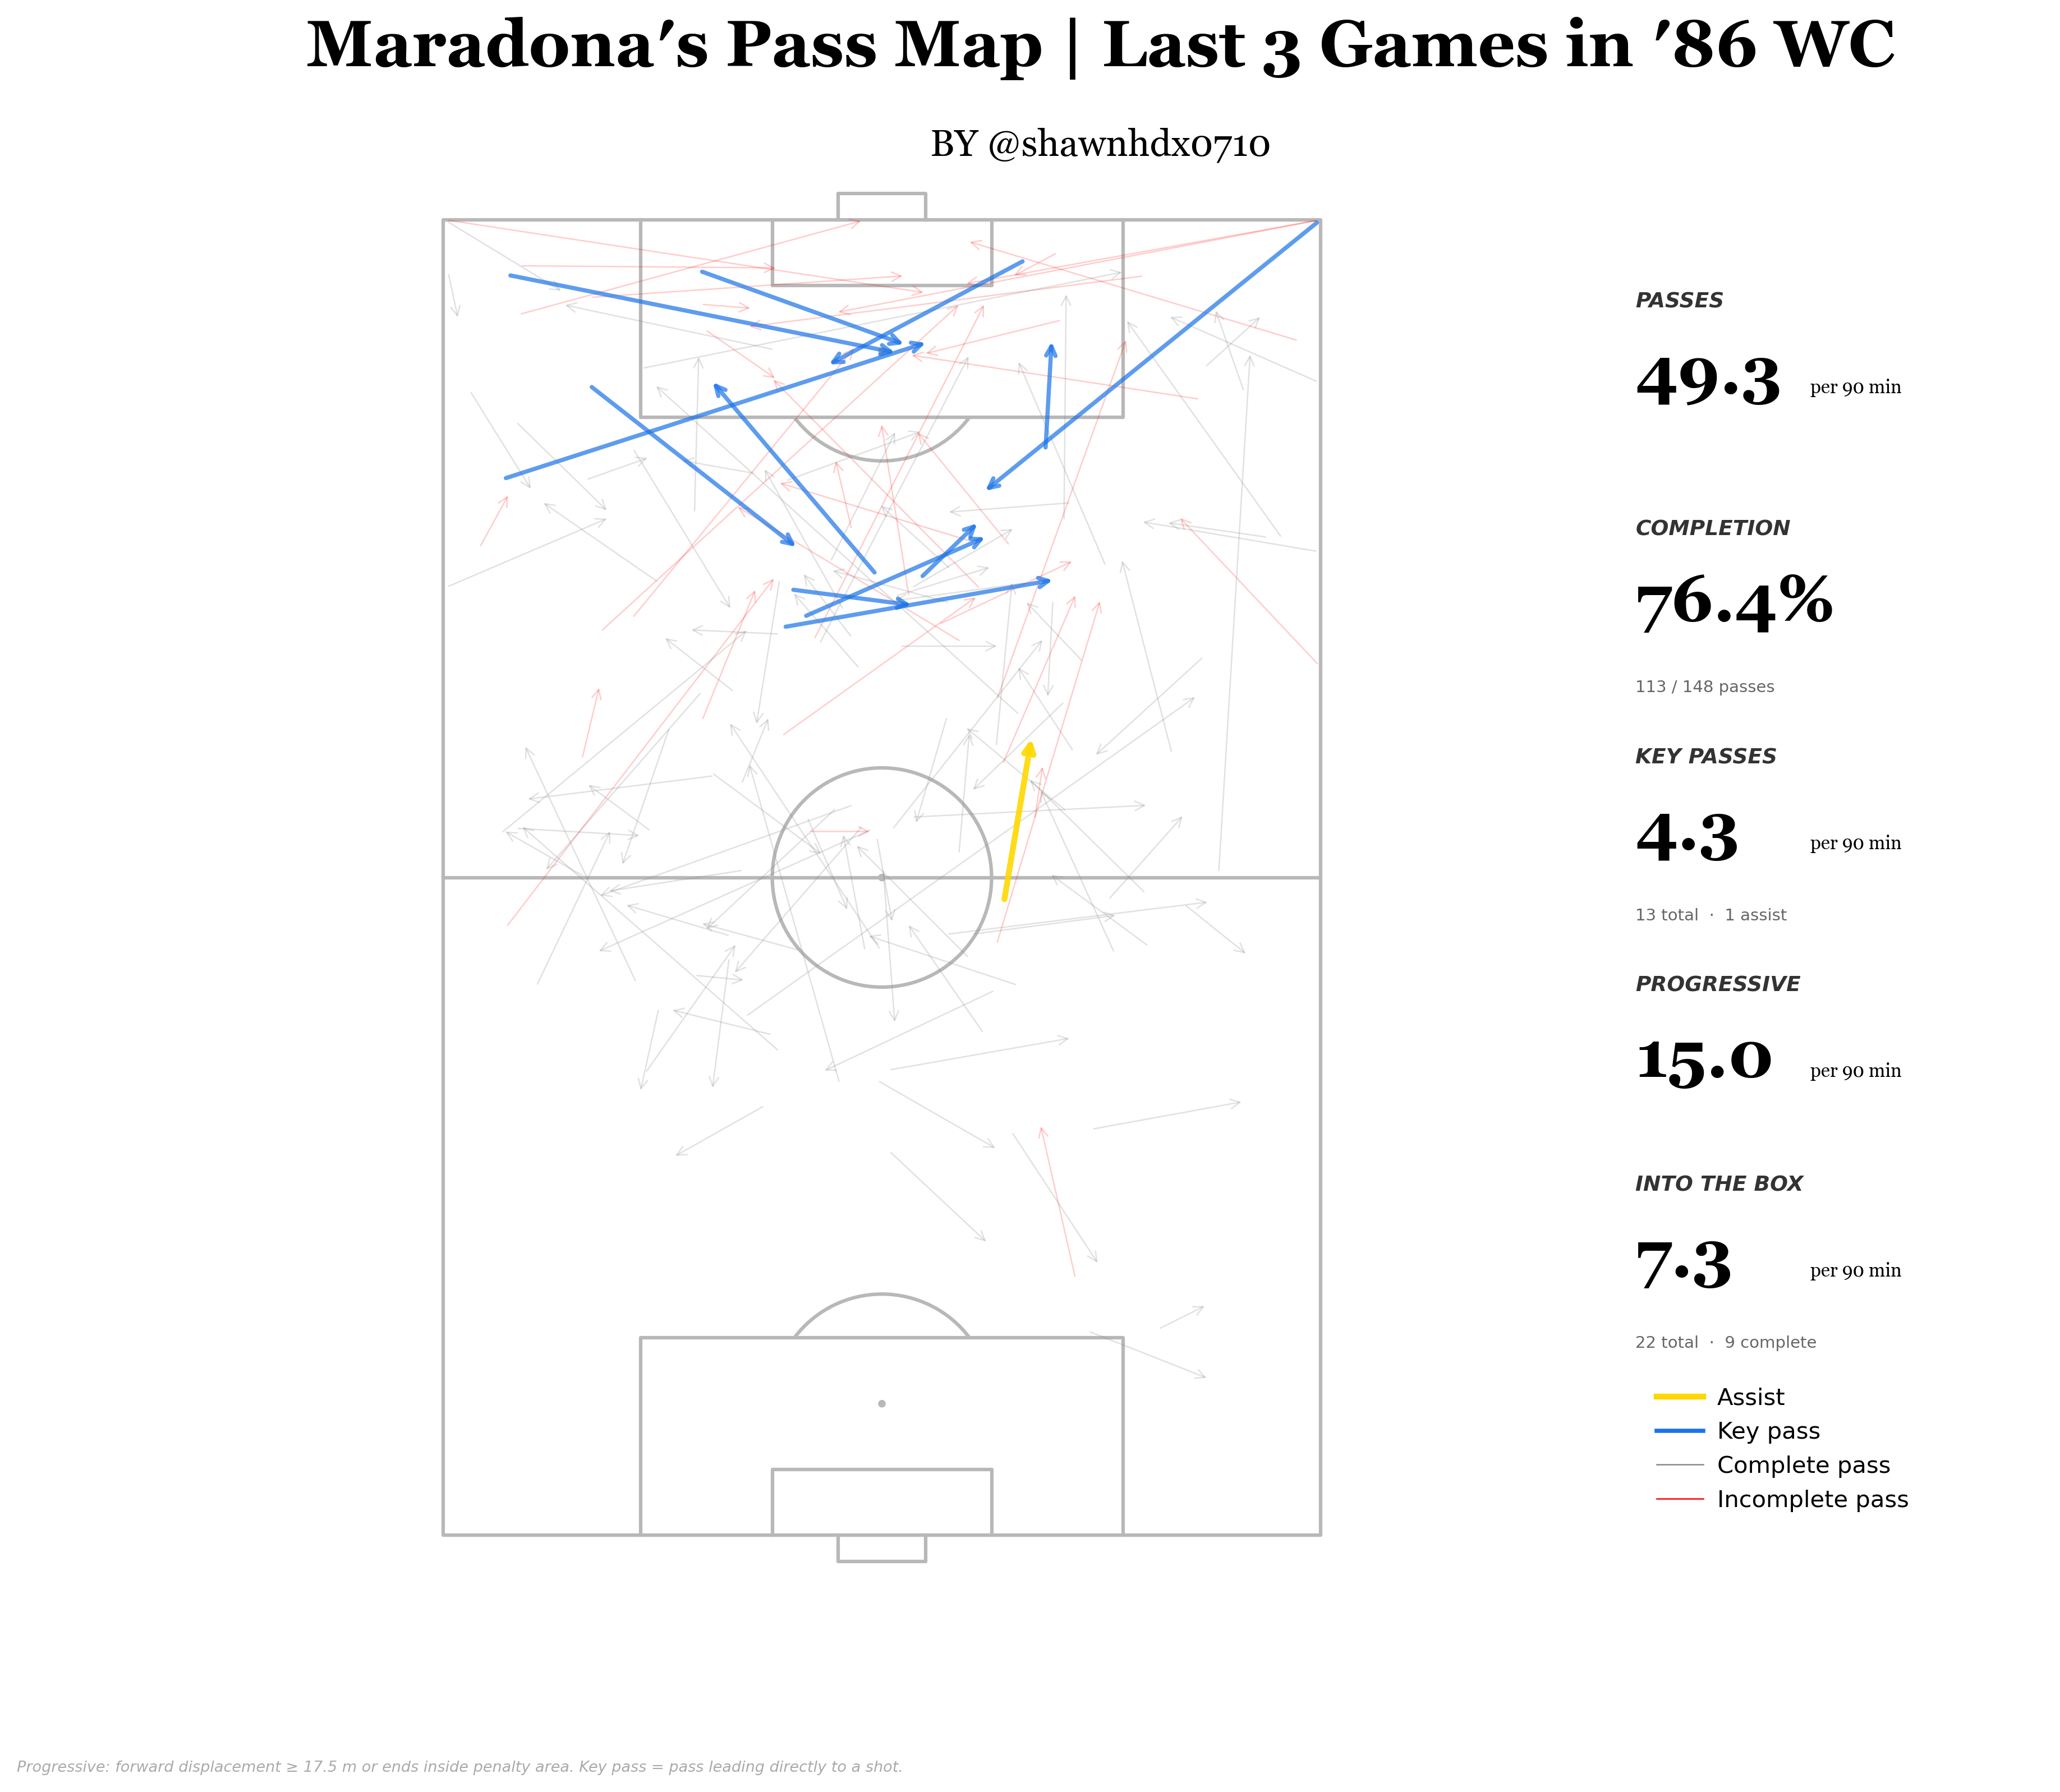

In [34]:
# ── Pass map + stats panel ────────────────────────────────────────

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mplsoccer import VerticalPitch
from matplotlib.lines import Line2D

def v_swap(loc):
    return (loc[1], loc[0])

passes = [e for e in maradona_events if e['type']['name'] == 'Pass']

# ── GridSpec layout ────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor('#FFFFFF')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.06)
ax = fig.add_subplot(gs[0, 0])
ax_stats = fig.add_subplot(gs[0, 1])

# ── Title ──────────────────────────────────────────────────────
fig.suptitle(
    "Maradona\u2032s Pass Map | Last 3 Games in \u203286 WC",
    fontsize=28, fontfamily='Georgia', fontweight='bold',
    color='#000000', x=0.5, y=0.96, ha='center', va='top'
)
fig.text(0.5, 0.9, 'BY @shawnhdx0710',
         fontsize=16, fontfamily='Georgia', color='#000000',
         ha='center', va='top')

# ── Pitch ──────────────────────────────────────────────────────
pitch = VerticalPitch(
    pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#B8B8B8',
    linewidth=1.5, half=False, goal_type='box',
    pad_top=5, pad_bottom=5, pad_left=5, pad_right=5,
)
pitch.draw(ax=ax)

# ── Draw passes by classification ──────────────────────────────
m = pass_metrics
MIN_DIST = 2

for p in passes:
    loc = p.get('location')
    end = p.get('pass', {}).get('end_location')
    if loc is None or end is None:
        continue
    sx, sy = v_swap(loc)
    ex, ey = v_swap(end)
    dist = ((ex - sx)**2 + (ey - sy)**2)**0.5
    if dist < MIN_DIST:
        continue

    pid = p['id']
    is_complete = p.get('pass', {}).get('outcome') is None

    if pid in m['assist_ids']:
        color, lw, alpha, z = '#FFD700', 2.5, 0.9, 9
    elif pid in m['key_pass_ids']:
        color, lw, alpha, z = '#1a73e8', 1.8, 0.70, 8
    elif is_complete:
        color, lw, alpha, z = "#888888", 0.6, 0.25, 4
    else:
        color, lw, alpha, z = "#ff0000", 0.6, 0.20, 3

    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, alpha=alpha),
                zorder=z)

# ── Stats Panel ────────────────────────────────────────────────
ax_stats.axis('off')
ax_stats.set_xlim(0, 1)
ax_stats.set_ylim(0, 1)

LEFT = 0.08

# Each block: label (y), value (y - 0.06), subtitle (y - 0.12)
# Blocks are spaced 0.15–0.17 apart vertically.

y = 0.90
# ── Block 1: Passes ──
ax_stats.text(LEFT, y, 'PASSES', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["passes_p90"]:.1f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(0.475, y - 0.06, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color='#000000', va='baseline')

y -= 0.16
# ── Block 2: Completion ──
ax_stats.text(LEFT, y, 'COMPLETION', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["completion_pct"]:.1f}%', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(LEFT, y - 0.11, f'{m["n_complete"]} / {m["n_passes"]} passes',
              fontsize=7, fontfamily='sans-serif', color='#666666', va='baseline')

y -= 0.16
# ── Block 3: Key Passes ──
ax_stats.text(LEFT, y, 'KEY PASSES', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["key_p90"]:.1f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(0.475, y - 0.06, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color='#000000', va='baseline')
ax_stats.text(LEFT, y - 0.11, f'{m["n_key"]} total  \u00b7  1 assist',
              fontsize=7, fontfamily='sans-serif', color='#666666', va='baseline')

y -= 0.16
# ── Block 4: Progressive ──
ax_stats.text(LEFT, y, 'PROGRESSIVE', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["prog_p90"]:.1f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(0.475, y - 0.06, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color='#000000', va='baseline')

y -= 0.14
# ── Block 5: Into the Box ──
ax_stats.text(LEFT, y, 'INTO THE BOX', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='baseline', style='italic')
ax_stats.text(LEFT, y - 0.06, f'{m["box_p90"]:.1f}', fontsize=28,
              fontfamily='Georgia', fontweight='bold', color='#000000', va='baseline')
ax_stats.text(0.475, y - 0.06, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color='#000000', va='baseline')
ax_stats.text(LEFT, y - 0.11, f'{m["n_box"]} total  \u00b7  {m["box_complete"]} complete',
              fontsize=7, fontfamily='sans-serif', color='#666666', va='baseline')

y -= 0.17

# ── Legend ──────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color='#FFD700', lw=2.5, label='Assist'),
    Line2D([0], [0], color='#1a73e8', lw=1.8, label='Key pass'),
    Line2D([0], [0], color='#888888', lw=0.6, label='Complete pass'),
    Line2D([0], [0], color='#ff0000', lw=0.6, label='Incomplete pass')
]
leg = ax_stats.legend(handles=legend_elements, loc='lower left',
                       fontsize=10, frameon=False, ncol=1,
                       bbox_to_anchor=(0.08, 0.04),
                       handletextpad=0.6, labelspacing=0.5)
for text in leg.get_texts():
    text.set_color("#000000")

# ── Methodology footnote ───────────────────────────────────────
fig.text(0.04, 0.01,
         'Progressive: forward displacement \u2265 17.5 m or ends inside penalty area. Key pass = pass leading directly to a shot.',
         fontsize=6.5, fontfamily='sans-serif', color='#AAAAAA',
         ha='left', va='bottom', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.savefig('./maradona-pass-map.svg', dpi=150, bbox_inches='tight',
            facecolor='#FFFFFF', edgecolor='none')
plt.show()


### Key fields for the pass map

- `location: [x, y]` — where the pass starts
- `pass.end_location: [x, y]` — where it lands
- `pass.outcome` — absent = completed; present with `.name` = 'Incomplete', 'Out', etc.
- `pass.length`, `pass.angle` — precomputed distance and direction
- `shot.key_pass_id` on a shot event links back to the assist/key-pass

## 7. Dribbles and Carries

How StatsBomb models Maradona's ball progression — and how to reconstruct his path.

In [16]:
import json as _json

# ── All dribbles and carries by Maradona ──────────────────────────
dribbles = [e for e in maradona_events if e['type']['name'] == 'Dribble']
carries  = [e for e in maradona_events if e['type']['name'] == 'Carry']

print(f'Dribbles: {len(dribbles)}')
print(f'Carries:  {len(carries)}')

# Dribble outcomes
from collections import Counter
d_outcomes = Counter(d.get('dribble', {}).get('outcome', {}).get('name', 'Complete') for d in dribbles)
print('Dribble outcomes:')
for o, c in d_outcomes.most_common():
    print(f'  {o}: {c}')
print(f'Carries:  {len(carries)}')

# Show full structure of one dribble
if dribbles:
    print('\n--- Full Dribble event ---')
    print(_json.dumps(dribbles[0], indent=2, ensure_ascii=False)[:1500])

# Show full structure of one carry
if carries:
    print('\n--- Full Carry event ---')
    print(_json.dumps(carries[0], indent=2, ensure_ascii=False)[:1500])

# Check if any dribble has end_location
for i, d in enumerate(dribbles):
    has_end = 'end_location' in d.get('dribble', {})
    if has_end:
        print(f'\nDribble {i} HAS end_location: {d["dribble"]["end_location"]}')
if not any('end_location' in d.get('dribble', {}) for d in dribbles):
    print('\n⚠ No dribble has end_location — only start point is recorded')

# Check carries for end_location
carries_with_end = sum(1 for c in carries if 'end_location' in c.get('carry', {}))
print(f'Carries with end_location: {carries_with_end}/{len(carries)}')

# Check Dribbled Past — opponents beaten by Maradona
dribbled_past = [e for e in maradona_events if e['type']['name'] == 'Dribbled Past']
# Dribbled Past — times Maradona was beaten by an opponent's dribble (he was defending)


Dribbles: 23
Carries:  182
Dribble outcomes:
  Complete: 16
  Incomplete: 7
Carries:  182

--- Full Dribble event ---
{
  "id": "c202d5b2-d6e1-4f0f-b860-06d7ecffa7e3",
  "index": 370,
  "period": 1,
  "timestamp": "00:08:24.960",
  "minute": 8,
  "second": 24,
  "type": {
    "id": 14,
    "name": "Dribble"
  },
  "possession": 22,
  "possession_team": {
    "id": 779,
    "name": "Argentina"
  },
  "play_pattern": {
    "id": 4,
    "name": "From Throw In"
  },
  "team": {
    "id": 779,
    "name": "Argentina"
  },
  "player": {
    "id": 38641,
    "name": "Diego Armando Maradona"
  },
  "position": {
    "id": 19,
    "name": "Center Attacking Midfield"
  },
  "location": [
    75.3,
    65.4
  ],
  "duration": 0.0,
  "under_pressure": true,
  "related_events": [
    "24637d6b-2bcf-4945-8136-2c24586b09be"
  ],
  "dribble": {
    "outcome": {
      "id": 8,
      "name": "Complete"
    }
  },
  "_match": "QF vs England"
}

--- Full Carry event ---
{
  "id": "16680050-d824-4226-bceb-

### What we can reconstruct

- **Dribbles**: single-point events (start location only in 1986 data). Mark the spot where Maradona beat a defender.
- **Carries**: have both `location` and `carry.end_location`. These give us **directed line segments** showing his path.
- **Dribbled Past**: events where Maradona *is the defender being beaten* (irrelevant).

To trace the Goal of the Century: sequence all dribbles + carries by timestamp within that possession, and connect the dots.

In [17]:
# ── Build Maradona's on-ball sequences ───────────────────────────
from collections import defaultdict

# 1 & 2: Filter Carries + Dribbles, sort by timestamp
on_ball = [e for e in maradona_events
           if e['type']['name'] in ('Carry', 'Dribble')]
on_ball.sort(key=lambda e: (e['_match'], e['period'], e['timestamp']))

print(f'Total on-ball events (Carry + Dribble): {len(on_ball)}')
print(f'  Carries:  {sum(1 for e in on_ball if e["type"]["name"] == "Carry")}')
print(f'  Dribbles: {sum(1 for e in on_ball if e["type"]["name"] == "Dribble")}')

# 3: Group by possession ID into sequences (consecutive same-possession events)
# A sequence breaks when possession_id changes
sequences = []
current_seq = []
current_poss = None

for e in on_ball:
    poss = e.get('possession')
    if poss != current_poss and current_seq:
        sequences.append(current_seq)
        current_seq = []
    current_poss = poss
    current_seq.append(e)
if current_seq:
    sequences.append(current_seq)

print(f'\nOn-ball sequences: {len(sequences)}')

# 4: Classify each sequence
pure_carry = []       # Carries only, no dribbles
dribble_involving = []  # Has at least one dribble

for seq in sequences:
        has_dribble = any(e['type']['name'] == 'Dribble' and e.get('location') is not None for e in seq)
        if has_dribble:
            dribble_involving.append(seq)
        else:
            pure_carry.append(seq)

print(f'  Pure Carry:            {len(pure_carry)}')
print(f'  Dribble-Involving:     {len(dribble_involving)}')

# Show a few sequences with context
print('\n--- Sample Dribble-Involving sequences ---')
for i, seq in enumerate(dribble_involving[:3]):
    match = seq[0]['_match']
    period = seq[0]['period']
    n_carries = sum(1 for e in seq if e['type']['name'] == 'Carry')
    n_dribbles = sum(1 for e in seq if e['type']['name'] == 'Dribble')
    start_time = f"{seq[0].get('minute',0)}:{seq[0].get('second',0):02d}"
    end_time = f"{seq[-1].get('minute',0)}:{seq[-1].get('second',0):02d}"
    print(f'  Seq {i+1}: {match} | {start_time}-{end_time} | '
          f'{n_carries} carries, {n_dribbles} dribbles | period {period}')

print('\n--- Sample Pure Carry sequences ---')
for i, seq in enumerate(pure_carry[:3]):
    match = seq[0]['_match']
    n_carries = len(seq)
    start_time = f"{seq[0].get('minute',0)}:{seq[0].get('second',0):02d}"
    print(f'  Seq {i+1}: {match} | {start_time} | {n_carries} carries')

Total on-ball events (Carry + Dribble): 205
  Carries:  182
  Dribbles: 23

On-ball sequences: 132
  Pure Carry:            114
  Dribble-Involving:     18

--- Sample Dribble-Involving sequences ---
  Seq 1: Final vs West Germany | 18:29-19:00 | 2 carries, 1 dribbles | period 1
  Seq 2: Final vs West Germany | 29:57-29:58 | 1 carries, 1 dribbles | period 1
  Seq 3: Final vs West Germany | 70:01-70:03 | 1 carries, 1 dribbles | period 2

--- Sample Pure Carry sequences ---
  Seq 1: Final vs West Germany | 1:59 | 1 carries
  Seq 2: Final vs West Germany | 2:37 | 1 carries
  Seq 3: Final vs West Germany | 4:23 | 1 carries


In [18]:
# ── Inspect a multi-event sequence ────────────────────────────────
import json as _json

multi = [s for s in sequences if len(s) >= 3]
print(f'Sequences with 3+ events: {len(multi)}')

def fmt(v):
    return f'{v:.0f}' if v is not None else '?'

for idx, seq in enumerate(sorted(multi, key=len, reverse=True)[:3]):
    match = seq[0]['_match']
    period = seq[0]['period']
    print(f'\n{"="*60}')
    print(f'#{idx+1} | {match} | Period {period} | {len(seq)} events')
    print(f'{"="*60}')
    for j, e in enumerate(seq):
        t = e['type']['name']
        loc = e.get('location', [None, None])
        end = e.get(t.lower(), {}).get('end_location', [None, None])
        ts = e.get('timestamp', '?')
        outcome = e.get(t.lower(), {}).get('outcome', {})
        out_str = outcome.get('name', 'ok') if outcome else 'ok'
        print(f'  {j+1}. [{ts}] {t}: ({fmt(loc[0])},{fmt(loc[1])}) → ({fmt(end[0])},{fmt(end[1])}) [{out_str}]')

Sequences with 3+ events: 17

#1 | QF vs England | Period 2 | 9 events
  1. [00:09:07.652] Carry: (55,56) → (54,56) [ok]
  2. [00:09:08.187] Dribble: (54,56) → (?,?) [Complete]
  3. [00:09:08.187] Carry: (54,56) → (87,69) [ok]
  4. [00:09:13.928] Dribble: (87,69) → (?,?) [Complete]
  5. [00:09:13.928] Carry: (87,69) → (97,55) [ok]
  6. [00:09:15.906] Dribble: (97,55) → (?,?) [Complete]
  7. [00:09:15.906] Carry: (97,55) → (113,49) [ok]
  8. [00:09:18.031] Dribble: (113,49) → (?,?) [Complete]
  9. [00:09:18.031] Carry: (113,49) → (113,50) [ok]

#2 | QF vs England | Period 2 | 6 events
  1. [00:36:16.424] Dribble: (65,44) → (?,?) [Complete]
  2. [00:36:17.364] Dribble: (73,46) → (?,?) [Complete]
  3. [00:36:17.364] Carry: (73,46) → (73,42) [ok]
  4. [00:36:17.844] Dribble: (73,42) → (?,?) [Complete]
  5. [00:36:17.844] Carry: (73,42) → (85,46) [ok]
  6. [00:36:22.542] Carry: (88,39) → (88,40) [ok]

#3 | QF vs England | Period 1 | 5 events
  1. [00:18:54.547] Carry: (87,55) → (87,55) [ok]

In [19]:
# ── Foul-Won Linking ─────────────────────────────────────────────
# Match each foul won by Maradona to the on-ball event that drew it

# Maradona's fouls won
fouls_won = [e for e in maradona_events if e['type']['name'] == 'Foul Won']
print(f'Fouls Won by Maradona: {len(fouls_won)}')

# Build quick lookup: all_events by id
evt_by_id = {e['id']: e for e in all_events}

# Link each foul to the preceding on-ball action
termination = {}  # event_id → 'foul' | 'incomplete_dribble' | None

for foul in fouls_won:
    foul_ts = foul.get('timestamp', '99:99:99.999')
    foul_poss = foul.get('possession')
    match = foul['_match']
    period = foul['period']
    
    # Search backward in all_events for the most recent carry/dribble
    best = None
    best_diff = 999
    for e in all_events:
        if e['_match'] != match or e['period'] != period:
            continue
        if e['type']['name'] not in ('Carry', 'Dribble'):
            continue
        if e.get('player', {}).get('id') != maradona_id:
            continue
        e_ts = e.get('timestamp', '99:99:99.999')
        # Simple string comparison works for HH:MM:SS.mmm format
        if e_ts < foul_ts:
            # Crude diff: just check possession match + proximity
            if e.get('possession') == foul_poss:
                # Use index in events list as rough timestamp proxy
                diff = all_events.index(foul) - all_events.index(e)
                if diff < best_diff and diff < 30:  # within ~30 events
                    best = e
                    best_diff = diff
    
    if best:
        termination[best['id']] = 'foul'
        print(f'  Linked: foul @ {foul.get("minute","?")}\u2032 → {best["type"]["name"]} id={best["id"]} (diff={best_diff} events)')

# Also tag incomplete dribbles as terminations
for e in maradona_events:
    if e['type']['name'] == 'Dribble':
        outcome = e.get('dribble', {}).get('outcome', {}).get('name', 'Complete')
        if outcome == 'Incomplete':
            termination[e['id']] = 'incomplete_dribble'

print(f'\nTermination tags: {len(termination)} ({sum(1 for v in termination.values() if v=="foul")} fouls, {sum(1 for v in termination.values() if v=="incomplete_dribble")} incomplete dribbles)')

# Inspect the foul linking accuracy
print('\n--- All linked fouls ---')
for eid, reason in sorted(termination.items()):
    if reason == 'foul':
        evt = evt_by_id.get(eid, {})
        loc = evt.get('location', [None, None])
        t = evt['type']['name']
        match = evt.get('_match', '?')
        minute = evt.get('minute', '?')
        print(f'  {match} | {minute}\u2032 | {t} at ({loc[0]:.0f},{loc[1]:.0f}) → foul')

print('\n--- All incomplete dribbles ---')
for eid, reason in sorted(termination.items()):
    if reason == 'incomplete_dribble':
        evt = evt_by_id.get(eid, {})
        loc = evt.get('location', [None, None])
        match = evt.get('_match', '?')
        minute = evt.get('minute', '?')
        print(f'  {match} | {minute}\u2032 | Dribble at ({loc[0]:.0f},{loc[1]:.0f}) → incomplete')

Fouls Won by Maradona: 24
  Linked: foul @ 2′ → Carry id=c17577b5-ee0b-455e-82a3-dec1f9259d80 (diff=2 events)
  Linked: foul @ 8′ → Carry id=1b0dfb8c-bf45-4dcf-a339-9055980c0eff (diff=3 events)
  Linked: foul @ 18′ → Carry id=21f41a27-1ced-47e7-bf7f-9c84056388b0 (diff=2 events)
  Linked: foul @ 21′ → Carry id=d6023431-2e74-4d26-84a3-7c99f40ea1fa (diff=3 events)
  Linked: foul @ 28′ → Carry id=7c427f14-eed1-4a13-8448-da3b484049f4 (diff=3 events)
  Linked: foul @ 31′ → Carry id=56e7800e-f73c-42e0-a21c-7ece097bdf4f (diff=3 events)
  Linked: foul @ 89′ → Carry id=4c0063d3-5854-4703-8e04-9ec825732d92 (diff=2 events)
  Linked: foul @ 35′ → Carry id=5325b832-398a-4442-bc94-e44e332cef37 (diff=3 events)
  Linked: foul @ 39′ → Carry id=369e1652-dcec-4991-92a8-74d76aade068 (diff=3 events)
  Linked: foul @ 42′ → Carry id=79270f79-23a6-4923-803b-8c72b2e17e04 (diff=3 events)
  Linked: foul @ 48′ → Carry id=9ae411f7-28a5-4a5c-95c5-c24c8f52b58e (diff=3 events)
  Linked: foul @ 57′ → Carry id=f6a1e636-

In [20]:
# ── Compute Maradona's Key Metrics ───────────────────────────────
import numpy as np

TOTAL_MIN = 270  # 3 matches × 90 min
N_MATCHES = 3
SB_LENGTH = 120
PITCH_M = 105
SB_TO_M = PITCH_M / SB_LENGTH
M_TO_YD = 1.09361
YD_TO_M = 0.9144

# ── CARRIES ──────────────────────────────────────────────────────
progressive_dist = 0
n_carries_all = 0
n_carries_filtered = 0  
MIN_DIST = 3        # Skip carries shorter than 3 yards for mapping/counting
PROG_THRESHOLD = 10  # Standard Opta definition for "Progressive" is 10 yards

for e in maradona_events:
    if e['type']['name'] != 'Carry':
        continue
    loc = e.get('location')
    end = e.get('carry', {}).get('end_location')
    if loc is None or end is None:
        continue
    
    n_carries_all += 1
    
    # Calculate Euclidean distance of the carry
    dx = end[0] - loc[0]
    dy = end[1] - loc[1]
    dist = (dx**2 + dy**2)**0.5
    
    # 1. Filter out micro-touches
    if dist >= MIN_DIST:
        n_carries_filtered += 1
        
        # 2. Only add to progressive distance if it meets the standard 10-yard threshold
        if dx >= PROG_THRESHOLD:  
            progressive_dist += dx  # Sum the forward component (X-axis displacement)

carries_per_90 = n_carries_filtered / N_MATCHES
prog_m_per_90 = (progressive_dist * SB_TO_M) / N_MATCHES
print(f'CARRIES')
print(f'  Carries per 90 min: {carries_per_90:.1f}')
print(f'  Prog. carry meters per 90 min: {prog_m_per_90:.1f}')

# ── DRIBBLES ─────────────────────────────────────────────────────
all_dribbles = [e for e in maradona_events if e['type']['name'] == 'Dribble' and e.get('location') is not None]
n_dribbles_total = len(all_dribbles)
n_dribbles_complete = sum(1 for d in all_dribbles if d.get('dribble', {}).get('outcome', {}).get('name', 'Complete') == 'Complete' or 'outcome' not in d.get('dribble', {}))

att_dribbles = [d for d in all_dribbles if d['location'][0] >= 80]
n_att_total = len(att_dribbles)
n_att_complete = sum(1 for d in att_dribbles if d.get('dribble', {}).get('outcome', {}).get('name', 'Complete') == 'Complete' or 'outcome' not in d.get('dribble', {}))

dribbles_per_90 = n_dribbles_total / N_MATCHES
dribble_success = n_dribbles_complete / n_dribbles_total * 100 if n_dribbles_total else 0
att_success = n_att_complete / n_att_total * 100 if n_att_total else 0

print(f'\nDRIBBLES')
print(f'  Dribbles per 90 min: {dribbles_per_90:.1f}')
print(f'  Overall success: {dribble_success:.0f}%')
print(f'  Attacking third success: {att_success:.0f}%')

# ── FOULS WON ────────────────────────────────────────────────────
n_fouls_won = len(fouls_won)
fouls_per_90 = n_fouls_won / N_MATCHES
YELLOWS_WON = 2  # hardcoded: opponents booked for fouling Maradona

print(f'\nFOULS WON')
print(f'  Fouls won per 90 min: {fouls_per_90:.1f}')
print(f'  Yellow cards won: {YELLOWS_WON}')

# Store for viz
metrics = {
    'carries_per_90': round(carries_per_90, 1),
    'prog_m_per_90': round(prog_m_per_90, 1),
    'dribbles_per_90': round(dribbles_per_90, 1),
    'dribble_success': round(dribble_success),
    'att_success': round(att_success),
    'fouls_per_90': round(fouls_per_90, 1),
    'yellows_won': YELLOWS_WON,
}
print(f'\n{metrics}')

CARRIES
  Carries per 90 min: 32.0
  Prog. carry meters per 90 min: 187.9

DRIBBLES
  Dribbles per 90 min: 7.7
  Overall success: 70%
  Attacking third success: 62%

FOULS WON
  Fouls won per 90 min: 8.0
  Yellow cards won: 2

{'carries_per_90': 32.0, 'prog_m_per_90': 187.9, 'dribbles_per_90': 7.7, 'dribble_success': 70, 'att_success': 62, 'fouls_per_90': 8.0, 'yellows_won': 2}


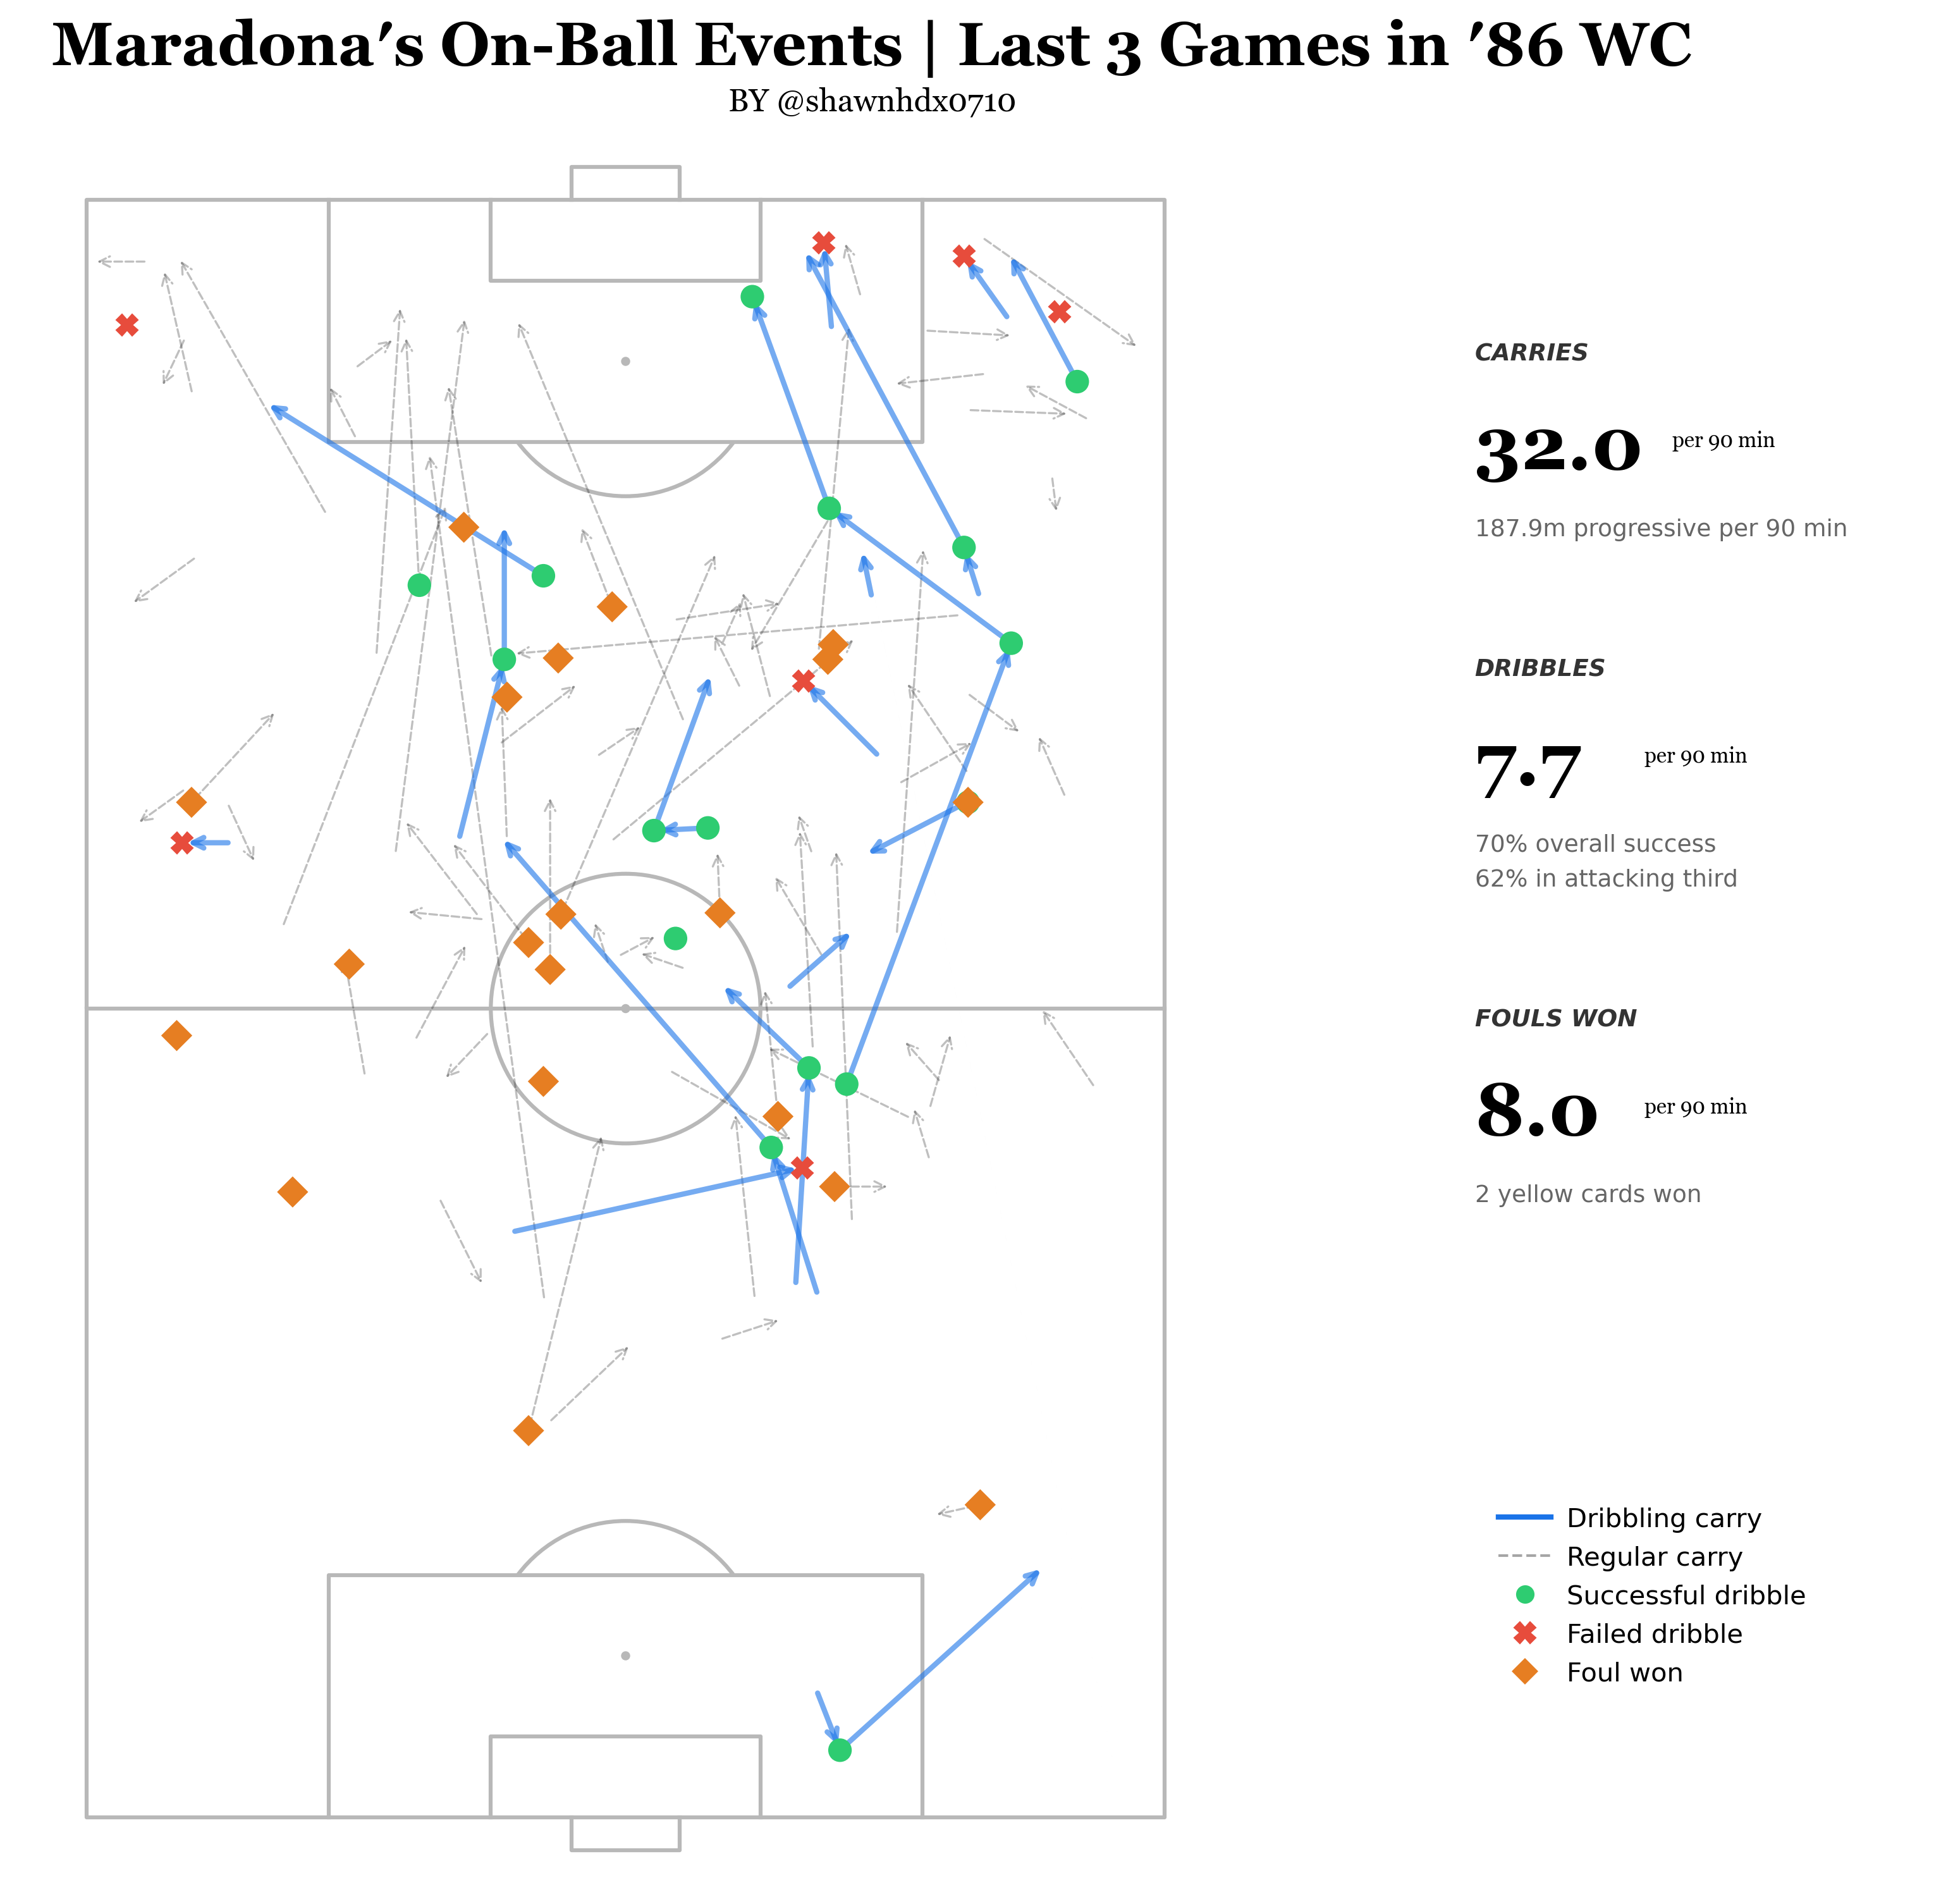

In [35]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mplsoccer import VerticalPitch
from matplotlib.lines import Line2D

def v_swap(loc):
    return (loc[1], loc[0])

MIN_DIST = 3

# GridSpec 
fig = plt.figure(figsize=(14, 12))
fig.patch.set_facecolor('#FFFFFF')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.06)
ax = fig.add_subplot(gs[0, 0])
ax_stats = fig.add_subplot(gs[0, 1])

# Title + credit
fig.suptitle(
    "Maradona\u2032s On-Ball Events | Last 3 Games in \u203286 WC",
    fontsize=23, fontfamily='Georgia', fontweight='bold',
    color='#000000', x=0.5, y=0.93, ha='center', va='top'
)
fig.text(0.5, 0.9, 'BY @shawnhdx0710',
         fontsize=12, fontfamily='Georgia', color="#000000",
         ha='center', va='top')

# Pitch
pitch = VerticalPitch(
    pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#B8B8B8',
    linewidth=1.5, half=False, goal_type='box',
    pad_top=5, pad_bottom=5, pad_left=5, pad_right=5,
)
pitch.draw(ax=ax)

# Pure Carry 
for seq in pure_carry:
    for e in seq:
        if e['type']['name'] != 'Carry':
            continue
        loc = e.get('location')
        end = e.get('carry', {}).get('end_location')
        if loc is None or end is None:
            continue
        sx, sy = v_swap(loc)
        ex, ey = v_swap(end)
        dist = ((ex - sx)**2 + (ey - sy)**2)**0.5
        if dist < MIN_DIST:
            continue
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color="#000000",
                                    lw=0.8, alpha=0.25, ls='--'),
                    zorder=3)

# Dribble-Involving 
for seq in dribble_involving:
    for e in seq:
        if e['type']['name'] != 'Carry':
            continue
        loc = e.get('location')
        end = e.get('carry', {}).get('end_location')
        if loc is None or end is None:
            continue
        sx, sy = v_swap(loc)
        ex, ey = v_swap(end)
        dist = ((ex - sx)**2 + (ey - sy)**2)**0.5
        if dist < MIN_DIST:
            continue
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color='#1a73e8',
                                    lw=2, alpha=0.6),
                    zorder=5)

# Dribble markers 
for seq in dribble_involving:
    for e in seq:
        if e['type']['name'] != 'Dribble':
            continue
        loc = e.get('location')
        if loc is None:
            continue
        dx, dy = v_swap(loc)
        outcome = e.get('dribble', {}).get('outcome', {}).get('name', 'Complete')
        term = termination.get(e['id'])
        if term == 'incomplete_dribble' or outcome == 'Incomplete':
            ax.plot(dx, dy, 'X', color='#e74c3c', markersize=8,
                    markeredgewidth=0.5, zorder=8)
        else:
            ax.scatter(dx, dy, s=80, c='#2ecc71', edgecolors='none',
                       linewidths=1, zorder=8)

# Foul-won diamonds 
evt_by_id = {e['id']: e for e in all_events}
for eid, reason in termination.items():
    if reason != 'foul':
        continue
    evt = evt_by_id.get(eid)
    if evt is None:
        continue
    loc = evt.get('location')
    if loc is None:
        continue
    dx, dy = v_swap(loc)
    ax.scatter(dx, dy, s=70, c='#e67e22', marker='D',
               edgecolors='none', zorder=9)

# Stats Panel 
ax_stats.axis('off')
ax_stats.set_xlim(0, 1)
ax_stats.set_ylim(0, 1)

y = 0.88

ax_stats.text(0.08, y, 'CARRIES', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='top', style='italic')
y -= 0.04
ax_stats.text(0.08, y, f"{metrics['carries_per_90']}", fontsize=28,
              fontfamily='Georgia', fontweight='bold', color="#000000", va='top')
ax_stats.text(0.475, y-0.01, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color="#000000", va='top')
y -= 0.06
ax_stats.text(0.08, y, f"{metrics['prog_m_per_90']}m progressive per 90 min", fontsize=9,
              fontfamily='sans-serif', color='#666666', va='top')


ax_stats.text(0.08, y-0.08, 'DRIBBLES', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='top', style='italic')
y -= 0.12
ax_stats.text(0.08, y, f"{metrics['dribbles_per_90']}", fontsize=28,
              fontfamily='Georgia', fontweight='bold', color="#000000", va='top')
ax_stats.text(0.42, y-0.01, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color="#000000", va='top')
y -= 0.06
ax_stats.text(0.08, y, f"{metrics['dribble_success']}% overall success", fontsize=9,
              fontfamily='sans-serif', color='#666666', va='top')
y -= 0.02
ax_stats.text(0.08, y, f"{metrics['att_success']}% in attacking third", fontsize=9,
              fontfamily='sans-serif', color='#666666', va='top')


ax_stats.text(0.08, y-0.08, 'FOULS WON', fontsize=9, fontfamily='sans-serif',
              fontweight='bold', color='#333333', va='top', style='italic')
y -= 0.12
ax_stats.text(0.08, y, f"{metrics['fouls_per_90']}", fontsize=28,
              fontfamily='Georgia', fontweight='bold', color="#000000", va='top')
ax_stats.text(0.42, y-0.01, 'per 90 min', fontsize=8,
              fontfamily='Georgia', color="#000000", va='top')
y -= 0.06
ax_stats.text(0.08, y, f"{metrics['yellows_won']} yellow cards won", fontsize=9,
              fontfamily='sans-serif', color='#666666', va='top')

# Legend
legend_elements = [
    Line2D([0], [0], color='#1a73e8', lw=2, label='Dribbling carry'),
    Line2D([0], [0], color="#A5A5A5", lw=1, ls='--', label='Regular carry'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
           markeredgecolor='none', markersize=7, lw=0, label='Successful dribble'),
    Line2D([0], [0], marker='X', color='#e74c3c', markersize=8,
           markeredgewidth=0.5, lw=0, label='Failed dribble'),
    Line2D([0], [0], marker='D', color='#e67e22', markerfacecolor='#e67e22',
           markeredgecolor='none', markersize=7, lw=0, label='Foul won'),
]
leg = ax_stats.legend(handles=legend_elements, loc='lower left',
                       fontsize=10, frameon=False, ncol=1,
                       bbox_to_anchor=(0.08, 0.1),
                       handletextpad=0.6, labelspacing=0.5)
for text in leg.get_texts():
    text.set_color("#000000")

plt.savefig('maradona-on-ball.svg', bbox_inches='tight',
            facecolor=fig.get_facecolor(), pad_inches=0.1)
plt.show()

## 7b. Maradona dropping deep — the hidden orchestrator

One of Maradona's most under-appreciated traits: he didn't just receive between the lines in the final third. Across all three knockout matches, he repeatedly dropped **into his own half** — sometimes as deep as the defensive third — to collect the ball from the back line and single-handedly drive Argentina forward.

We filter every Ball Receipt where Maradona is in his own half (`sb_x < 60`, i.e. behind the centre circle) and trace what happened next in the same possession: progressive carries, line-breaking passes, dribbles, fouls won, and whether the sequence led to a shot. The table below highlights the top orchestration moments — look these up in match footage.

In [ ]:
# ── Deep orchestration moments ───────────────────────────────────────
# Filter Ball Receipts in Maradona's own half (sb_x < 60),
# then trace the possession chain to classify what he did next.

import json as _json

DEEP_THRESHOLD = 60   # sb_x < 60 = own half / behind centre circle
PROG_PASS_DX  = 20   # forward displacement to count as 'progressive pass'
PROG_CARRY_DX = 15   # forward displacement to count as 'progressive carry'

# Build an event-by-id lookup across all matches
evt_by_id = {e['id']: e for e in all_events}

def possession_has_shot(pos_id):
    """Does this possession contain a shot by anyone?"""
    for e in all_events:
        if e.get('possession') == pos_id and e['type']['name'] == 'Shot':
            return True
    return False

# Collect every deep Ball Receipt with its orchestration signature
moments = []

for e in maradona_events:
    if 'Receipt' not in e['type']['name']:
        continue
    loc = e.get('location')
    if not loc or loc[0] >= DEEP_THRESHOLD:
        continue

    ts = e['timestamp']
    period = e['period']
    pos_id = e.get('possession')
    match = e['_match']
    pp = e.get('play_pattern', {}).get('name', 'Regular Play')

    # ── All Maradona events in this possession ──
    chain = sorted(
        [ev for ev in maradona_events if ev.get('possession') == pos_id],
        key=lambda x: x['index']
    )

    # ── Classify actions ──
    has_pass     = any(ev['type']['name'] == 'Pass' for ev in chain)
    has_carry    = any(ev['type']['name'] == 'Carry' for ev in chain)
    has_dribble  = any(ev['type']['name'] == 'Dribble' for ev in chain)
    has_shot     = any(ev['type']['name'] == 'Shot' for ev in chain)
    has_foul_won = any(ev['type']['name'] == 'Foul Won' for ev in chain)

    # Progressive actions — forward component only
    best_prog_pass = 0
    for p in [ev for ev in chain if ev['type']['name'] == 'Pass']:
        ploc = p.get('location')
        pend = p.get('pass', {}).get('end_location')
        if ploc and pend:
            dx = pend[0] - ploc[0]
            if dx > best_prog_pass:
                best_prog_pass = dx

    best_prog_carry = 0
    for c in [ev for ev in chain if ev['type']['name'] == 'Carry']:
        cloc = c.get('location')
        cend = c.get('carry', {}).get('end_location')
        if cloc and cend:
            dx = cend[0] - cloc[0]
            if dx > best_prog_carry:
                best_prog_carry = dx

    prog_pass   = best_prog_pass >= PROG_PASS_DX
    prog_carry  = best_prog_carry >= PROG_CARRY_DX
    led_to_shot = possession_has_shot(pos_id)

    # ── Build description ──
    parts = []
    if prog_pass:
        parts.append(f'progressive pass (+{best_prog_pass:.0f} sb_x)')
    elif has_pass:
        parts.append('pass')
    if prog_carry:
        parts.append(f'progressive carry (+{best_prog_carry:.0f} sb_x)')
    elif has_carry:
        parts.append('carry')
    if has_dribble:
        parts.append('dribble(s)')
    if has_foul_won:
        parts.append('foul won')
    if has_shot:
        parts.append('SHOT')
    if led_to_shot:
        parts.append('-> possession led to shot')

    depth_zone = 'defensive third' if loc[0] < 40 else 'midfield'

    # Score: progressive actions + shot involvement + dribbles + fouls
    score = (1 if prog_pass else 0) + (1 if prog_carry else 0) \
          + (2 if led_to_shot else 0) + (1 if has_dribble else 0) + (1 if has_foul_won else 0)

    moments.append({
        'match': match,
        'timestamp': ts,
        'period': period,
        'depth_zone': depth_zone,
        'x': loc[0],
        'y': loc[1],
        'play_pattern': pp,
        'chain_len': len(chain),
        'description': ' | '.join(parts),
        'score': score,
        'chain': chain,
    })

moments.sort(key=lambda m: m['score'], reverse=True)

# ── Print the top moments ──
print('TOP DEEP ORCHESTRATION MOMENTS\n')
print(f'Found {len(moments)} Ball Receipts in own half across all 3 matches.\n')

for i, m in enumerate(moments[:5]):
    # Convert period+timestamp to match-clock minute
    parts = m['timestamp'].split(':')
    period_min = int(parts[0])
    period_sec = int(parts[1].split('.')[0])
    if m['period'] == 1:
        match_min = period_min
    else:
        match_min = 45 + period_min
    
    print(f'── Moment {i+1} ──')
    print(f'  Match:      {m["match"]}')
    print(f'  Timestamp:  {m["timestamp"]} (period {m["period"]}) — ~{match_min}\' match clock')
    print(f'  Location:   sb_x={m["x"]:.0f} ({m["depth_zone"]}), sb_y={m["y"]:.0f}')
    print(f'  Origin:     {m["play_pattern"]}')
    print(f'  Actions:    {m["description"]}')
    print(f'  Chain:       {m["chain_len"]} Maradona events in this possession')
    
    # Show the event sequence
    for ev in m['chain'][:10]:
        etype = ev['type']['name']
        eloc  = ev.get('location')
        coord = f'({eloc[0]:5.1f}, {eloc[1]:5.1f})' if eloc else 'N/A'
        print(f'    [{ev["index"]:4d}] {etype:20s} {coord}')
    print()

print('—' * 60)
print('Methodology: Ball Receipt* events where sb_x < 60 (own half).')
print('Progressive pass: forward displacement >= 20 sb_x (~17.5 m).')
print('Progressive carry: forward displacement >= 15 sb_x (~13.1 m).')
print('Score = progressive_pass + progressive_carry + 2*led_to_shot + dribble + foul_won.')


TOP DEEP ORCHESTRATION MOMENTS

Found 54 Ball Receipts in own half across all 3 matches.

── Moment 1 ──
  Match:      SF vs Belgium
  Timestamp:  00:38:50.327 (period 1) — ~0' match clock
  Location:   sb_x=39 (defensive third), sb_y=54
  Origin:     Regular Play
  Actions:    pass | progressive carry (+23 sb_x) | dribble(s) | foul won | -> possession led to shot
  Chain:       15 Maradona events in this possession
    [1223] Ball Receipt*        ( 74.0,  29.7)
    [1232] Ball Receipt*        ( 65.7,  33.3)
    [1233] Carry                ( 65.7,  33.3)
    [1234] Pass                 ( 65.7,  33.1)
    [1243] Ball Receipt*        ( 88.8,  36.0)
    [1244] Carry                ( 88.8,  36.0)
    [1245] Pass                 ( 91.5,  37.3)
    [1428] Ball Receipt*        ( 38.6,  54.3)
    [1429] Carry                ( 38.6,  54.3)
    [1431] Dribble              ( 49.7,  50.8)

── Moment 2 ──
  Match:      QF vs England
  Timestamp:  00:09:07.652 (period 2) — ~45' match clock
  Locatio

## 8. On-Ball Activity Heatmap

Where Maradona *lived* with the ball — every possession event across all 3 matches,
with carries sampled along their full path for proportional density.

In [27]:
# ── Build on-ball heatmap data ─────────────────────────────────────
import numpy as np

# Event types that represent Maradona WITH the ball
ON_BALL_TYPES = {'Ball Receipt*', 'Carry', 'Pass', 'Dribble',
                 'Shot', 'Miscontrol', 'Dispossessed'}

def v_swap(loc):
    return (loc[1], loc[0])  # StatsBomb → VerticalPitch

points_x, points_y = [], []

for e in maradona_events:
    if e['type']['name'] not in ON_BALL_TYPES:
        continue
    loc = e.get('location')
    if loc is None:
        continue
    t = e['type']['name']
    
    if t == 'Carry':
        end = e.get('carry', {}).get('end_location')
        if end is None:
            points_x.append(loc[1]); points_y.append(loc[0])
            continue
        # Sample evenly-spaced points along carry path
        dx = end[0] - loc[0]
        dy = end[1] - loc[1]
        dist = (dx**2 + dy**2)**0.5
        n_pts = max(2, int(dist / 3))  # ~1 point per 3 SB units
        for i in range(n_pts):
            frac = i / (n_pts - 1) if n_pts > 1 else 0
            sb_x = loc[0] + dx * frac
            sb_y = loc[1] + dy * frac
            x_v, y_v = v_swap([sb_x, sb_y])
            points_x.append(x_v)
            points_y.append(y_v)
    else:
        # Single-point event
        x_v, y_v = v_swap(loc)
        points_x.append(x_v); points_y.append(y_v)

pts = np.array([points_x, points_y])
print(f'Total KDE sample points: {len(points_x):,}')
print(f'  From carries: {sum(1 for e in maradona_events if e["type"]["name"]=="Carry" and e.get("location"))} carries → multiple path points each')
print(f'  From other events: ~{sum(1 for e in maradona_events if e["type"]["name"] in ON_BALL_TYPES and e["type"]["name"]!="Carry" and e.get("location"))} single-point events')

Total KDE sample points: 990
  From carries: 182 carries → multiple path points each
  From other events: ~438 single-point events


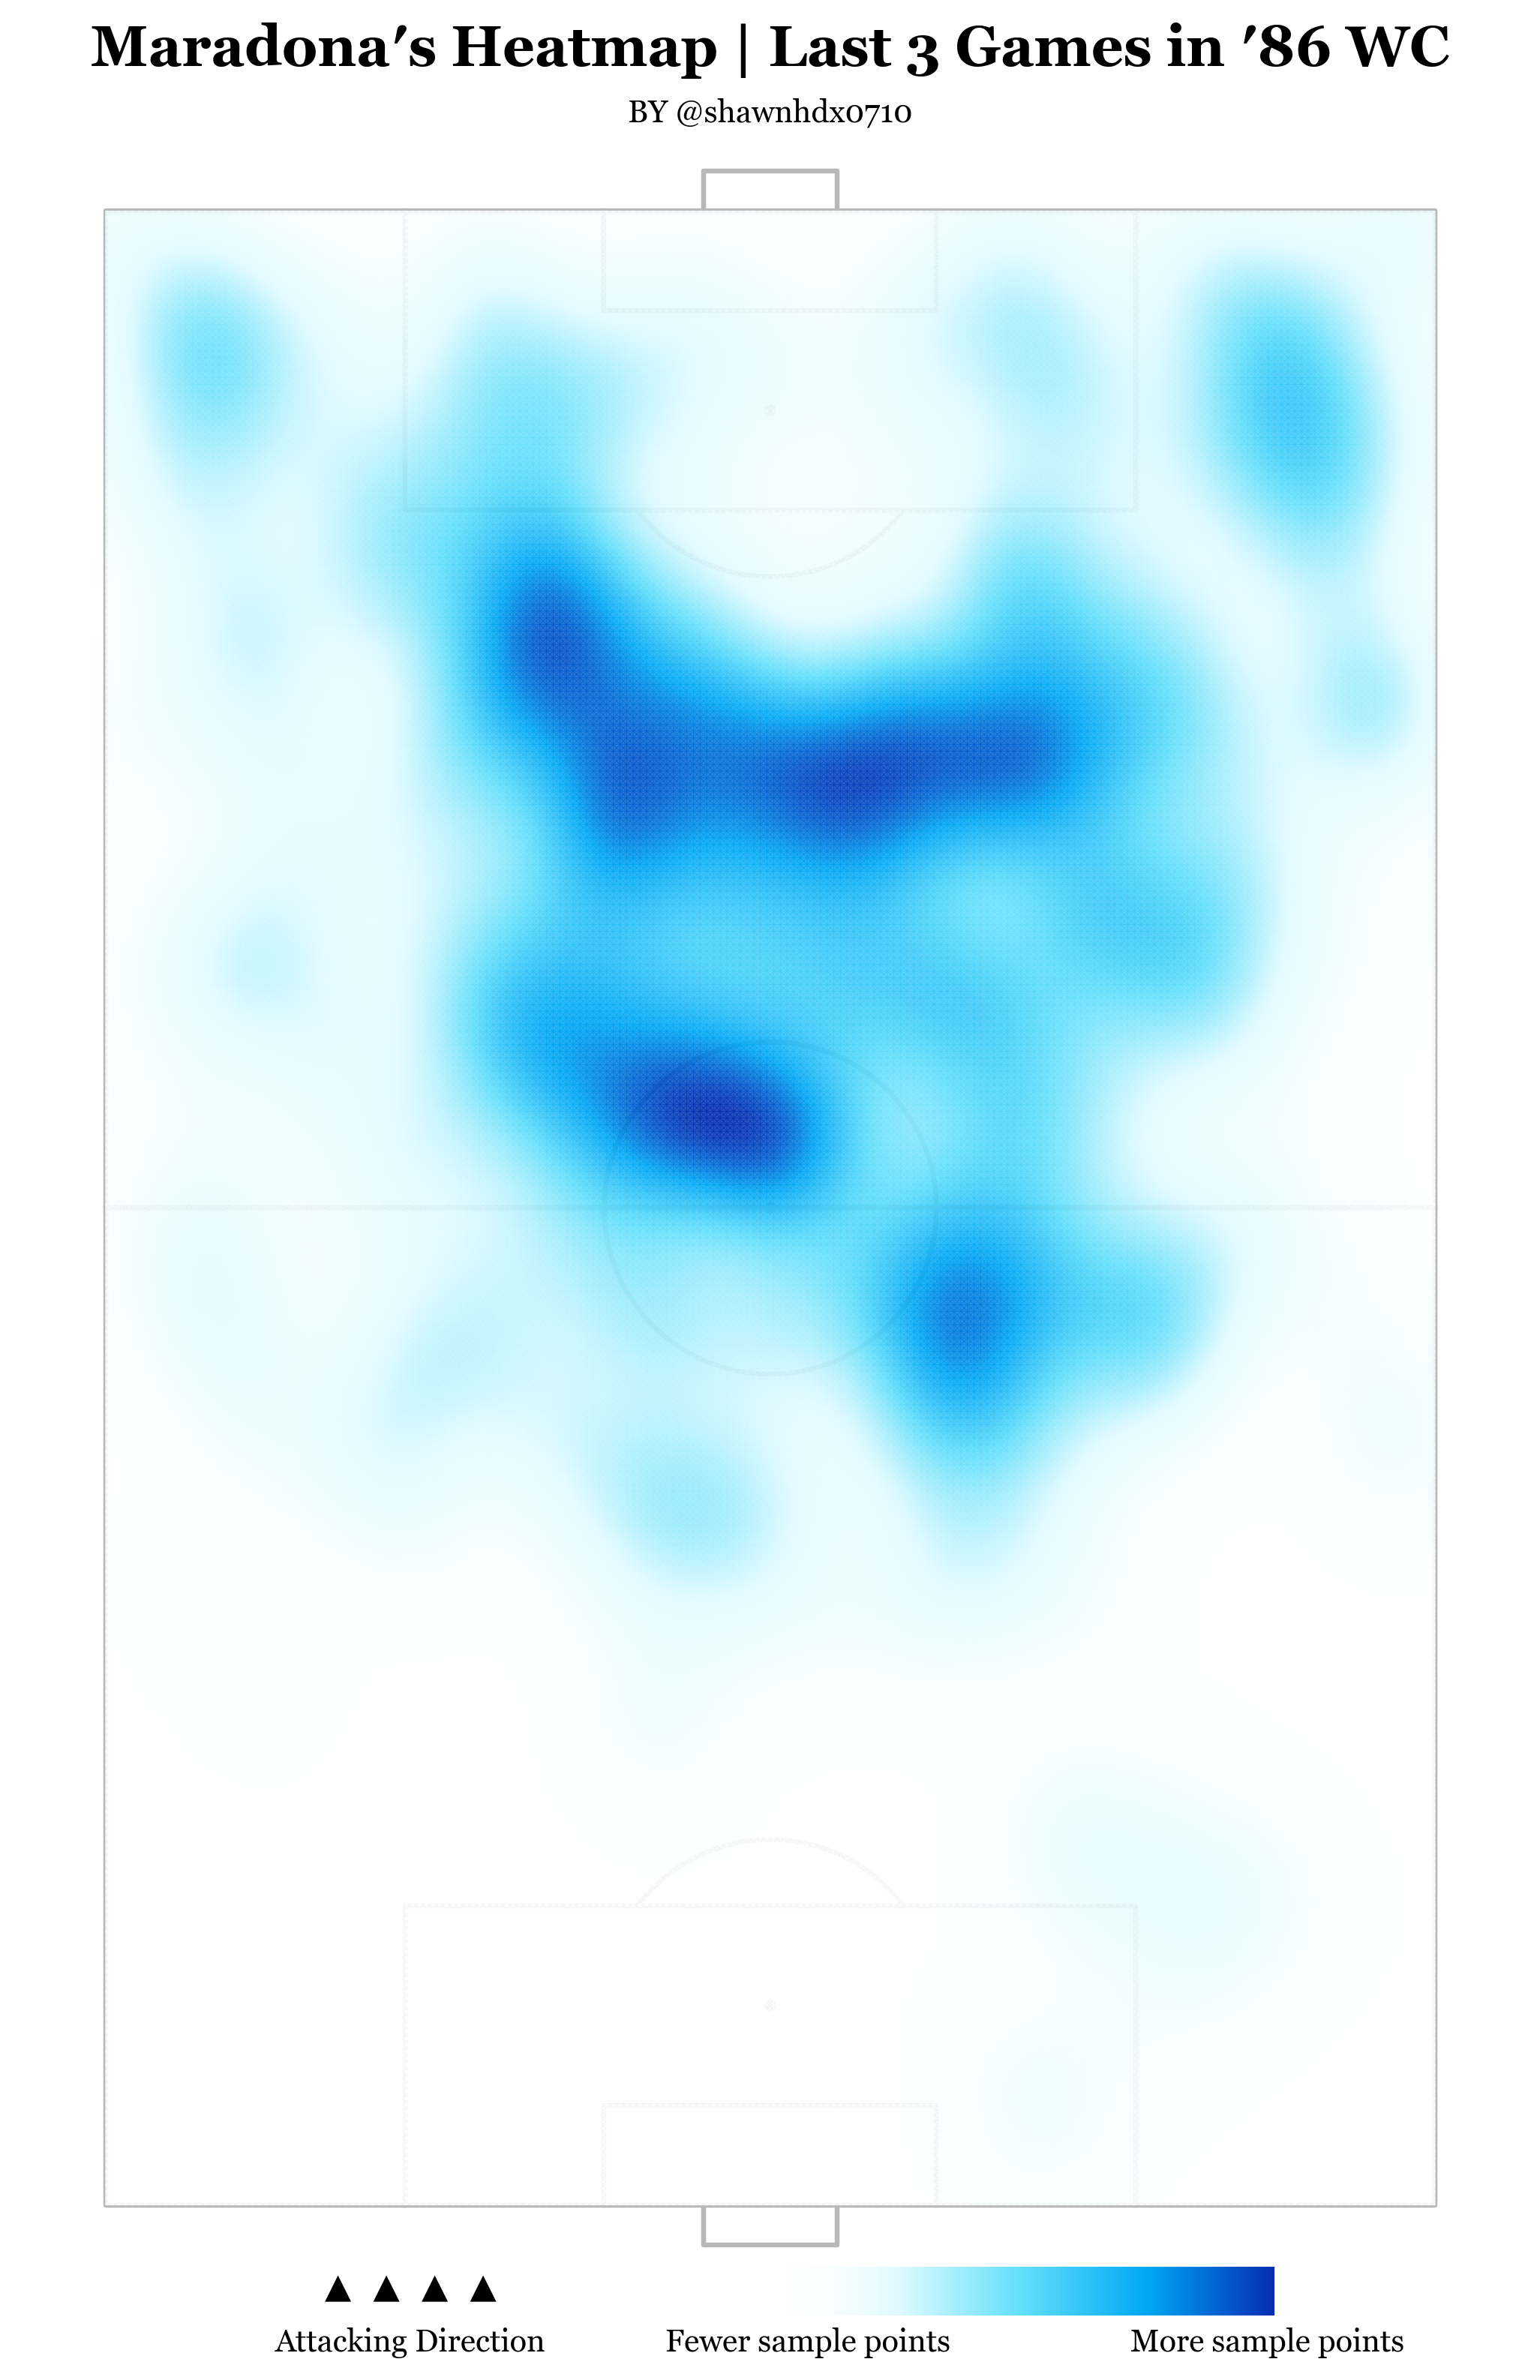

In [36]:
# KDE Heatmap
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

# Fit KDE
kde = gaussian_kde(pts, bw_method=0.18) 

# Evaluate on a fine grid over the pitch
X_GRID, Y_GRID = np.mgrid[0:80:200j, 0:120:300j]
positions = np.vstack([X_GRID.ravel(), Y_GRID.ravel()])
density = kde(positions).reshape(X_GRID.shape)

# color
colors = ['#FFFFFF00', "#E0FBFF", "#61DFFB", "#00A7F5", "#042DB3"]
cmap = LinearSegmentedColormap.from_list('heat', colors, N=256)

# Plot
fig, ax = plt.subplots(figsize=(8, 12))
fig.patch.set_facecolor('#FFFFFF')

pitch = VerticalPitch(
    pitch_type='statsbomb', pitch_color='#FFFFFF', line_color='#B8B8B8',
    linewidth=1.5, half=False, goal_type='box',
    pad_top=5, pad_bottom=5, pad_left=5, pad_right=5,
)
pitch.draw(ax=ax)

# Heatmap layer
ax.pcolormesh(X_GRID, Y_GRID, density, cmap=cmap, alpha=0.85,
              shading='gouraud', zorder=2, rasterized=True)

pitch.draw(ax=ax)

# Title + credit
ax.set_title(
    "Maradona\u2032s Heatmap | Last 3 Games in \u203286 WC",
    fontsize=18, fontfamily='Georgia', fontweight='bold',
    color='#000000', loc='center', pad=20
)
ax.text(0.5, 1, 'BY @shawnhdx0710',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=10, fontfamily='Georgia', color="#000000")

# Bottom margin for legend
fig.subplots_adjust(left=0.08, right=0.92, top=0.95, bottom=0.15)

# Direction
fig.text(0.3, 0.15, '▲  ▲  ▲  ▲', fontsize=11, color="#000000",
         ha='center', va='center', fontfamily='sans-serif')
fig.text(0.3, 0.13, 'Attacking Direction', fontsize=10,
         ha='center', va='center', fontfamily='Georgia',
         color="#000000")

# Colorbar
cbar_ax = fig.add_axes([0.5, 0.14, 0.28, 0.018])
import matplotlib.colorbar as mcb
from matplotlib.colors import Normalize
cb = mcb.ColorbarBase(cbar_ax, cmap=cmap, norm=Normalize(vmin=0, vmax=1),
                       orientation='horizontal')
cb.outline.set_visible(False)
cb.set_ticks([])
fig.text(0.6, 0.13, 'Fewer sample points', fontsize=10, fontfamily='Georgia',
         ha='right', va='center', color="#000000")
fig.text(0.7, 0.13, 'More sample points', fontsize=10, fontfamily='Georgia',
         ha='left', va='center', color="#000000")

plt.savefig('maradona-heatmap.svg', bbox_inches='tight',
            facecolor=fig.get_facecolor(), pad_inches=0.1)
plt.show()